## Configure

In [106]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [172]:
from os.path import join
from pathlib import Path
import json
import yaml
from yaml.loader import SafeLoader
import pickle
import pandas as pd
import geopandas as gpd
import numpy as np
import rioxarray as rio
from scipy import stats
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import matplotlib.ticker as mtick
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import contextily as cx

In [108]:
# Name the fips, statefips, stateabbr, and nation that
# we are using for this analysis
fips_args = {
    'FIPS': ['42101'], 
    'STATEFIPS': ['42'],
    'STATEABBR': ['PA'],
    'NATION': ['US']
}
FIPS = fips_args['FIPS'][0]
NATION = fips_args['NATION'][0]

ABS_DIR = Path().absolute().parents[0]

CONFIG_FILEP = join(ABS_DIR, 'config', 'config.yaml')
# Open the config file and load
with open(CONFIG_FILEP) as f:
    CONFIG = yaml.load(f, Loader=SafeLoader)

# Wildcards for urls
URL_WILDCARDS = CONFIG['url_wildcards']

# Get the file extensions for api endpoints
API_EXT = CONFIG['api_ext']

# Get the CRS constants
NSI_CRS = CONFIG['nsi_crs']

# Dictionary of ref_names
REF_NAMES_DICT = CONFIG['ref_names']

# Dictionary of ref_id_names
REF_ID_NAMES_DICT = CONFIG['ref_id_names']

# Coefficient of variation
# for structure values
COEF_VARIATION = CONFIG['coef_var']

# First floor elevation dictionary
FFE_DICT = CONFIG['ffe_dict']

# Number of states of the world
N_SOW = CONFIG['sows']

# Data for flood depth grids
# Get hazard model variables
HAZ_FILEN = CONFIG['haz_filename']
# Get CRS for depth grids
HAZ_CRS = CONFIG['haz_crs']
# Ensemble members
HAZ_NENS = CONFIG['haz_nens']
# Number of columns for each depth grid
HAZ_NCOLS = CONFIG['haz_ncols']
# Num rows for each depth grid
HAZ_NROWS = CONFIG['haz_nrows']
# Lower left x coordinate
HAZ_XLL = CONFIG['haz_xll']
# Lower left y coordinate
HAZ_YLL = CONFIG['haz_yll']
# Cell resolution
HAZ_RES = CONFIG['haz_res']
# NODATA values
HAZ_NODATA = CONFIG['haz_nodata']

# Get the files we need downloaded
DOWNLOAD = pd.json_normalize(CONFIG['download'], sep='_').T

# We can also specify the filepath to the
# raw data directory
FR = join(ABS_DIR, "data", "raw")

# And external - where our hazard data should be
FE = join(FR, "external")

# Set up interim and results directories as well
# We already use "FR" for raw, we use "FO" 
# because you can also think of results
# as output
FI = join(ABS_DIR, "data", "interim")
FO = join(ABS_DIR, "data", "results")

# For figures
FIG_DIR = join(ABS_DIR, "fig")

# "Raw" data directories for exposure, vulnerability (vuln) and
# administrative reference files
EXP_DIR_R = join(FR, "exp")
VULN_DIR_R = join(FR, "vuln")
REF_DIR_R = join(FR, "ref")
# Haz is for depth grids
HAZ_DIR_R = join(FE, "haz")
# Pol is for NFHL
POL_DIR_R = join(FR, "pol")

# Unzip directory 
UNZIP_DIR = join(FR, "unzipped")

# We want to process unzipped data and move it
# to the interim directory where we keep
# processed data
# Get the filepaths for unzipped data
# We unzipped the depth grids (haz) and 
# ddfs (vuln) into the "external"/ subdirectory
HAZ_DIR_UZ = join(UNZIP_DIR, "external", "haz")
POL_DIR_UZ = join(UNZIP_DIR, "pol")
REF_DIR_UZ = join(UNZIP_DIR, "ref")
VULN_DIR_UZ = join(UNZIP_DIR, "external", "vuln")

# Our study domain
CLIP_SHP_FILEP = join(HAZ_DIR_UZ, 'RIFT_domain', 'domain_1.shp')

# "Interim" data directories
EXP_DIR_I = join(FI, "exp")
VULN_DIR_I = join(FI, "vuln")
REF_DIR_I = join(FI, "ref")
# Haz is for depth grids
HAZ_DIR_I = join(FI, "haz")
# Pol is for NFHL
POL_DIR_I = join(FI, "pol")

## Load data for analysis and plotting

In [109]:
# Experiments and benchmarks
with open(join(FO, 'main_exp.pkl'), 'rb') as f:
    all_results = pickle.load(f)

with open(join(FO, 'benchmarks.pkl'), 'rb') as f:
    all_benchmarks = pickle.load(f)

In [110]:
# Spatial data
clip_geo = gpd.read_file(CLIP_SHP_FILEP)
tract_ref = gpd.read_file(join(REF_DIR_I, FIPS, 'tract.gpkg'))[['GEOID', 'geometry']]
cejst = gpd.read_file(join(VULN_DIR_I, 'social', FIPS, 'cejst.gpkg'))
sovi = gpd.read_file(join(VULN_DIR_I, 'social', FIPS, 'sovi.gpkg'))

# Inventories
# Spatial
nsi_clip_out = gpd.read_file(join(EXP_DIR_I, FIPS, 'nsi_res.gpkg'))
phil_inv_out = gpd.read_file(join(EXP_DIR_I, FIPS, 'phil_res.gpkg'))
# Ensembles
phil_inv_ens = pd.read_parquet(join(EXP_DIR_I, FIPS, 'phil_inv_ens.pqt'))
nsi_inv_ens = pd.read_parquet(join(EXP_DIR_I, FIPS, 'nsi_inv_ens.pqt'))

# Data to link inventories to tracts
phil_refs = pd.read_parquet(join(EXP_DIR_I, FIPS, 'phil_ref.pqt'))
nsi_refs = pd.read_parquet(join(EXP_DIR_I, FIPS, 'nsi_ref.pqt'))

# Depths across inundation model ensembles
nsi_depths_df = pd.read_parquet(join(EXP_DIR_I, FIPS, 'nsi_depths.pqt')).set_index('fd_id')
phil_depths_df = pd.read_parquet(join(EXP_DIR_I, FIPS, 'phil_depths.pqt')).set_index('bfid')

## Postprocessing results for figures

There are a few datasets that will be helpful for analyzing and visualizing the results. 

First, we want to identify consistent records between the structure inventories and categorize records in terms of their match types across inventories. This is the basis for most of our main results. For each match type, we want to know about damage discrepancies, rank discrepancies, etc., so there is a lot of processing here. 

Second, we want to have results across all experiments summarized at the census tract level. A main inquiry of research is whether damage discrepancies at the property level cancel out at the scales most typical for using prospective damage estimates in support of decisions. 

Finally, we want to calculate how well the various experiments compare to the "best" representation of damages using the Philly inventory. 

In [111]:
# Can only choose depth grids that we generated ensembles for
dg_id = '009'
dam_col = 'naccs_loss_' + dg_id

### Get match types

First we calculate match types across inventories

In [112]:
# Reference of nsi records linked to philly footprints
lnk_nsi_loc = gpd.sjoin(nsi_clip_out,
                        phil_inv_out,
                        predicate='within',
                        how='inner')

# Use the spatial links to add bfid to the nsi data
fd_bfid_lnk = dict(zip(lnk_nsi_loc['fd_id'], lnk_nsi_loc['bfid']))
nsi_match = nsi_inv_ens.reset_index()
nsi_match['bfid'] = nsi_match['fd_id'].map(fd_bfid_lnk)
# We will link up all the records across inventories
# including those w/o a match in the other in order to define
# different match categories
nsi_match.loc[nsi_match['bfid'].isnull(), 'bfid'] = nsi_match.loc[nsi_match['bfid'].isnull()]['fd_id']

match_df = nsi_match.merge(phil_inv_ens.reset_index(),
                           on='bfid',
                           suffixes=['_nsi', '_phil'],
                           how='outer')

matches = match_df.groupby(['bfid', 'num_story_phil', 'found_type_phil',
                            'occtype_phil', 'occtype_nsi',
                            'num_story_nsi', 'found_type_nsi']).size().reset_index()

matches['story_match'] = 0
matches.loc[matches['num_story_phil'] == matches['num_story_nsi'],
            'story_match'] = 1

matches['found_type_match'] = 0
matches.loc[matches['found_type_phil'] == matches['found_type_nsi'],
            'found_type_match'] = 1

matches['occ_match'] = 0
matches.loc[matches['occtype_phil'] == matches['occtype_nsi'],
            'occ_match'] = 1

matches.loc[(matches['story_match'] == 0) & (matches['found_type_match'] == 0),
            'Structure Matches'] = 'Location Only'

matches.loc[((matches['story_match'] == 1) &
             (matches['found_type_match'] == 1) &
             (matches['occ_match'] == 1)),
            'Structure Matches'] = 'All'

matches.loc[((matches['story_match'] == 1) &
             (matches['found_type_match'] == 1) &
             (matches['occ_match'] == 0)),
            'Structure Matches'] = 'Basement & Stories'

matches.loc[((matches['story_match'] == 1) &
             (matches['found_type_match'] == 0) &
             (matches['occ_match'] == 0)),
            'Structure Matches'] = 'Stories'

matches.loc[((matches['story_match'] == 0) &
             (matches['found_type_match'] == 1) &
             (matches['occ_match'] == 0)),
            'Structure Matches'] = 'Basement'

matches.loc[((matches['story_match'] == 0) &
             (matches['found_type_match'] == 0) &
             (matches['occ_match'] == 1)),
            'Structure Matches'] = 'Occupancy'

matches.loc[((matches['story_match'] == 1) &
             (matches['found_type_match'] == 0) &
             (matches['occ_match'] == 1)),
            'Structure Matches'] = 'Stories & Occupancy'

matches.loc[((matches['story_match'] == 0) &
             (matches['found_type_match'] == 1) &
             (matches['occ_match'] == 1)),
            'Structure Matches'] = 'Basement & Occuapncy'

match_agg_l = ['Stories', 'Basement', 'Occupancy', 'Stories & Occupancy',
               'Basement & Stories', 'Basement & Occuapncy']
matches.loc[matches['Structure Matches'].isin(match_agg_l),
            'Structure Matches'] = 'Location & Subset'

match_dict = dict(zip(matches['bfid'].astype(int), matches['Structure Matches']))

phil_only = match_df[(~match_df['bfid'].isin(matches['bfid'])) & (match_df['fd_id'].isnull())]
phil_only['Structure Matches'] = 'Unmatched Philly'
# Sometimes there will be a NSI property matched to a Philly property, but it 
# doesn't match our inventory. We limited nsi_inv_ens and phil_inv_ens to 
# <= 3 stories, for instance. If the NSI has the wrong entry for this, it will
# be the same as "NSI Not In Philly" for our purposes because that refers to
# the inventory match
nsi_only = match_df[(~match_df['bfid'].isin(matches['bfid'])) & (match_df['fd_id'].notnull())]
nsi_only['Structure Matches'] = 'NSI Not In Philly'

phil_only_dict = dict(zip(phil_only['bfid'].astype(int), phil_only['Structure Matches']))
nsi_only_dict = dict(zip(nsi_only['bfid'].astype(int), nsi_only['Structure Matches']))

match_dict |= phil_only_dict
match_dict |= nsi_only_dict

/var/folders/d2/g0h08s551zb2hz_ws2g4ggh400hbd0/T/ipykernel_38354/428776935.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  phil_only['Structure Matches'] = 'Unmatched Philly'
/var/folders/d2/g0h08s551zb2hz_ws2g4ggh400hbd0/T/ipykernel_38354/428776935.py:90: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nsi_only['Structure Matches'] = 'NSI Not In Philly'


Then we calculate damage discrepancies across inventories. In our case study, we are using the ensemble to estimate "best guess" damage estimates with the Philly inventory, so we are taking the discrepancy relative to the *mean*. 

In [113]:
main_nsi = all_benchmarks['original']['no_adj'].join(nsi_inv_ens).reset_index()

main_phil = all_results['original']['phil:no_adj']
# main_phil = main_phil.groupby('bfid')[dam_col].mean().reset_index()
main_phil = main_phil.merge(phil_inv_ens.reset_index(), on='bfid')

main_nsi['bfid'] = main_nsi['fd_id'].map(fd_bfid_lnk)

# Calculate relative damage for each and include that in the mean step after merge
main_nsi['rel_loss'] = main_nsi[dam_col]/main_nsi['val_struct']
main_phil['rel_loss'] = main_phil[dam_col]/main_phil['val_s']

# Merge depths in
main_nsi[dg_id] = main_nsi['fd_id'].map(nsi_depths_df[dg_id])*3.28084
main_phil[dg_id] = main_phil['bfid'].map(phil_depths_df[dg_id])*3.28084

merge_cols = ['bfid', dam_col, dg_id, 'rel_loss', 'num_story', 'found_type', 'occtype']

# Do a quick update of occtype to RES1 if basement property
main_phil.loc[main_phil['found_type'] == 'B', 'occtype'] = 'RES1'

phil_mean = main_phil.groupby('bfid').agg({dam_col: 'mean',
                                           dg_id: 'first',
                                           'rel_loss': 'mean',
                                           'occtype': 'first',
                                           'num_story': 'first',
                                           'found_type': 'first'}).reset_index()

test = main_nsi.merge(phil_mean[merge_cols],
                      suffixes=['_nsi', '_phil'],
                      on='bfid',
                      how='outer')

# If bfid is null or Philly damage is 0, use fd_id in its place so we have a unique id
# We also look at Philly damage being 0 because if that's the case there's no depth
# for the property at that bfid and we want to use the fd_id instead for merging
# depths in later
fd_id_mask = test['bfid'].isnull() # | test[dam_col+'_phil'].isnull()
test.loc[fd_id_mask, 'bfid'] = test.loc[fd_id_mask, 'fd_id']

# NSI buildings can be stacked on top of each other so we'll aggregate these
# and treat them like one structure
test_gb = test.groupby(['bfid']).agg({dam_col + '_nsi': 'sum',
                                      dam_col + '_phil': 'first',
                                      dg_id + '_nsi': 'first',
                                      dg_id + '_phil': 'first',
                                      'rel_loss_nsi': 'first',
                                      'rel_loss_phil': 'first'}).reset_index().fillna(0)

test_gb['bfid'] = test_gb['bfid'].astype(int)

test_gb['nsi_rank'] = test_gb[dam_col+'_nsi'].rank(ascending=False, method='min')
test_gb['phil_rank'] = test_gb[dam_col+'_phil'].rank(ascending=False, method='min')

# Dam and rank diff
test_gb['diff'] = test_gb[dam_col+'_nsi'] - test_gb[dam_col+'_phil']
test_gb['diff_rel'] = test_gb['rel_loss_nsi'] - test_gb['rel_loss_phil']
test_gb['rank_diff'] = test_gb['nsi_rank'] - test_gb['phil_rank']
test_gb['diff_m'] = test_gb['diff']/1e6

# For visualization purposes, create an artificial high fillna value
test_gb.loc[test_gb['nsi_rank'].isnull(), 'nsi_rank'] = len(test_gb) 
test_gb.loc[test_gb['phil_rank'].isnull(), 'phil_rank'] = len(test_gb)


test_gb['Matches'] = test_gb['bfid'].map(match_dict)# .fillna('Philly Only (No Match)')

# Get depth back in 
test_gb['depth_ft'] = (test_gb['bfid'].map(phil_depths_df[dg_id])*3.28084)
test_gb.loc[test_gb['depth_ft'].isnull(),
            'depth_ft'] = test_gb['bfid'].map(nsi_depths_df[dg_id])*3.28084

# Id for "true" damage
test_gb['phil_dam'] = 0
test_gb.loc[test_gb['bfid'].isin(phil_mean['bfid']), 'phil_dam'] = 1

# Assign depths based on damage source
test_gb.loc[test_gb['phil_dam'] == 1, 'depth_ft'] = test_gb.loc[test_gb['phil_dam'] == 1, dg_id+'_phil']
test_gb.loc[test_gb['phil_dam'] == 0, 'depth_ft'] = test_gb.loc[test_gb['phil_dam'] == 0, dg_id+'_nsi']

# Update match column where no Philly damages
# test_gb.loc[test_gb['phil_dam'] == 0, 'Matches'] = 'NSI Only (No Match)'

# We only want to keep columns where there is damage in either record 
test_gb = test_gb.loc[(test_gb['phil_dam'] == 1) | (test_gb[dam_col+'_nsi'] > 0)]

# Get tract_id back in
test_gb['tract_id'] = test_gb['bfid'].map(phil_refs.set_index('bfid')['tract_id'])
test_gb.loc[test_gb['tract_id'].isnull(),
            'tract_id'] = test_gb['bfid'].map(nsi_refs.set_index('fd_id')['tract_id'])

# For cumulative discrepancies we are doing it using the mean from the ensemble
# as our best guess damage for the property

test_gb['depth_plot'] = test_gb['depth_ft'].round(1)
test_gb['cm_diff'] = test_gb.sort_values('depth_plot').groupby('Matches')['diff'].transform('cumsum')/1e6

test_gb['cm_diff_agg'] = test_gb.sort_values('depth_plot')['diff'].transform('cumsum')/1e6

### Census tract results 

In [114]:
def create_comparison_dataframe(results_dict,
                                benchmark_dict,
                                phil_refs,
                                nsi_refs, 
                                phil_inventory,
                                nsi_inventory, 
                                dam_col,
                                ref_id,
                                result_keys=['phil:no_adj'],
                                benchmark_keys=['no_adj']):
    """
    Create a dataframe that links building IDs to different reference IDs
    for both Philadelphia and NSI data and aggregates damage and value
    to the level of the reference ID.
    
    Parameters:
    -----------
    results_dict : dict
        Dictionary containing ensemble results
    benchmark_dict : dict
        Dictionary containing benchmark results
    phil_refs : DataFrame
        DataFrame linking Philadelphia building IDs to reference IDs
    nsi_refs : DataFrame
        DataFrame linking NSI building IDs to reference IDs
    phil_inventory : DataFrame
        Philadelphia inventory data
    nsi_inventory : DataFrame
        NSI inventory data
    dam_col : str
        Column name for damage values
    ref_id: str
        Name of the spatial reference (e.g., "tract_id"). Must be in
        the phil_refs and nsi_refs dataframes
    result_keys : list, default=['phil:no_adj']
        Key to access specific results in results_dict
    benchmark_keys : list, default=['no_adj']
        Key to access specific benchmarks in benchmark_dict
        
    Returns:
    --------
    DataFrame
        Comparison dataframe with damage and property values for both datasets aggregated to
        the level of ref_id
    """
    # Process each result key
    result_dfs = {}
    for key in result_keys:
        # Determine which reference dataframe to use based on key prefix
        if key.startswith('phil'):
            refs = phil_refs
            id_col = 'bfid'
            inventory = phil_inventory
        else:
            refs = nsi_refs
            id_col = 'fd_id'
            inventory = nsi_inventory

        # Process ensemble results
        temp = results_dict[key]
        if ref_id not in temp.columns:
            temp = temp.merge(refs, on=id_col)

        temp_gb = temp.groupby(['sow_ind', ref_id]).agg({dam_col: 'sum'}).reset_index()
        loss_by_ref = temp_gb.groupby(ref_id)[dam_col].mean()
        
        # Calculate reference-level property values
        if ref_id not in inventory.columns:
            inventory = inventory.merge(refs[[id_col, ref_id]], on=id_col)
        
        ref_vals = inventory.groupby(ref_id).agg({'val_struct': ['median', 'sum', 'size']})
        ref_vals = ref_vals.reset_index()
        ref_vals.columns = [ref_id, 'median_val', 'total_val', 'n_prop']
        
        # Create result dataframe
        result_df = pd.DataFrame({
            dam_col: loss_by_ref,
            'median_val': ref_vals.set_index(ref_id)['median_val'],
            'total_val': ref_vals.set_index(ref_id)['total_val'],
            'n_prop': ref_vals.set_index(ref_id)['n_prop']
        })
        
        result_df = result_df[result_df[dam_col].notnull()]
        result_dfs[key] = result_df
   
    # Process each benchmark key
    benchmark_dfs = {}
    for key in benchmark_keys:
        refs = nsi_refs
        id_col = 'fd_id'
        inventory = nsi_inventory

    # Process benchmark results
        temp = benchmark_dict[key].reset_index()
        
        if ref_id not in inventory.columns:
            inventory = inventory.merge(refs[[id_col, ref_id]], on=id_col)
        
        if id_col in temp.columns:
            temp_w_refs = temp.merge(inventory, on=id_col)
            temp_gb = temp_w_refs.groupby([ref_id])[[dam_col]].sum().reset_index()
        else:
            # If benchmark already has ref_id, just group by it
            temp_gb = temp.groupby([ref_id])[[dam_col]].sum().reset_index()
        
        # Calculate reference-level property values
        ref_vals = inventory.groupby(ref_id).agg({'val_struct': ['median', 'sum', 'size']})
        ref_vals = ref_vals.reset_index()
        ref_vals.columns = [ref_id, 'median_val', 'total_val', 'n_prop']
        
        # Merge with property values
        temp_gb = temp_gb.merge(ref_vals, on=ref_id)
        benchmark_dfs[key] = temp_gb.set_index(ref_id)

    # Combine all dataframes
    all_dfs = []
    
    # Process result dataframes
    for key, df in result_dfs.items():
        df_reset = df.reset_index()
        df_reset.columns = [ref_id] + [f"{col}_{key.split(':')[0]}" for col in df.columns]
        all_dfs.append(df_reset)
    
    # Process benchmark dataframes
    for key, df in benchmark_dfs.items():
        df_reset = df.reset_index()
        df_reset.columns = [ref_id] + [f"{col}_nsi" for col in df.columns]
        all_dfs.append(df_reset)

    # Merge all dataframes
    if all_dfs:
        result = all_dfs[0]
        for df in all_dfs[1:]:
            result = result.merge(df, on=ref_id, how='outer')
        
        return result.fillna(0)
    else:
        return pd.DataFrame()


In [115]:
comp = create_comparison_dataframe(
    all_results['original'], 
    all_benchmarks['original'],
    phil_refs,
    nsi_refs,
    phil_inv_ens,
    nsi_inv_ens,
    dam_col=dam_col,
    ref_id='tract_id',
    result_keys=['phil:no_adj', 'nsi_ddfs:no_adj', 'nsi_unsafe:no_adj',
                 'nsi_phil:no_adj', 'phil_unsafe:no_adj', 'phil_nsi:no_adj'],
    benchmark_keys=['no_adj']
)

comp_geo = tract_ref.merge(comp, left_on='GEOID', right_on='tract_id')

### Skill metrics for each experiment compared to baseline

In [116]:
def calculate_metrics(comp_df, exps, dam_col, baseline='phil'):
    """Calculate various skill metrics for each experiment compared to baseline."""
    metrics = {}
    
    # Baseline values
    baseline_loss = comp_df[f"{dam_col}_{baseline}"]/1e6
    baseline_val = comp_df[f"median_val_{baseline}"]
    baseline_rank = baseline_loss.rank(ascending=False)
    baseline_total = baseline_loss.sum()
    
    # Top 20% tracts in baseline
    top20_threshold = int(len(comp_df) * 0.1)
    top20_tracts = baseline_loss.nlargest(top20_threshold).index
    
    for exp in exps:
        exp_metrics = {}
        
        # Calculate losses and ranks
        exp_loss = comp_df[f"{dam_col}_{exp}"]/1e6
        exp_val = comp_df[f"median_val_{exp}"]
        exp_rank = exp_loss.rank(ascending=False)
        exp_total = exp_loss.sum()
        
        # Total discrepancy metrics
        exp_metrics['total_discrepancy_dollar'] = exp_total - baseline_total
        exp_metrics['total_discrepancy_pct'] = 100 * (exp_total - baseline_total) / baseline_total
        
        # RMSE metrics
        exp_metrics['rmse_tract'] = np.sqrt(mean_squared_error(baseline_loss, exp_loss))
        
        # Correlation between structure value and damages

        exp_metrics['corr_val_dam'] = (stats.pearsonr(exp_loss, exp_val)[0] -
                                       stats.pearsonr(baseline_loss, baseline_val)[0])
        

        # Rank correlation metrics
        exp_metrics['rank_correlation'] = stats.spearmanr(exp_rank, baseline_rank)[0]
        
        # Top percentage rank correlation
        exp_metrics['rank_correlation_top20'] = stats.spearmanr( 
            exp_rank[baseline_rank <= len(top20_tracts)],
            baseline_rank[baseline_rank <= len(top20_tracts)]
        )[0]
        
        # Type 1 and Type 2 errors for top 20%
        # Type 1: Baseline says it's top 20%, experiment says it's not
        type1_error = len(set(top20_tracts) - set(exp_loss.nlargest(top20_threshold).index))
        exp_metrics['type1_error_count'] = type1_error 
        exp_metrics['type1_pct'] = 100*type1_error/top20_threshold
        
        # Type 2: Experiment says it's top 20%, baseline says it's not
        type2_error = len(set(exp_loss.nlargest(top20_threshold).index) - set(top20_tracts))
        exp_metrics['type2_error_count'] = type2_error 
        exp_metrics['type2_pct'] = 100*type2_error/top20_threshold
        
        # Count of matched ranks
        exp_metrics['matched_top_rank_pct'] = (
             exp_rank[exp_rank <= len(top20_tracts)] -
             baseline_rank[baseline_rank <= len(top20_tracts)] == 0
            ).sum()*100/len(top20_tracts)


        # std error of ranks
        exp_metrics['std_rank'] = np.std(
            baseline_rank - exp_rank
        )

        metrics[exp] = exp_metrics
    
    return metrics

In [117]:
# Calculate metrics
exps = ['nsi', 'nsi_ddfs', 'nsi_unsafe', 'nsi_phil', 'phil_nsi', 'phil_unsafe']
metrics = calculate_metrics(comp, exps, dam_col)

## Figures

### Figure 1
Examples of inventory matches across datasets along with their damage discrepancies from contrasting deterministic and probabilistic approaches. Panel A shows several blocks of Philadelphia residential building footprints and National Structure Inventory (NSI) point locations, coded by match type. The flood depth basemap is from the Hurricane Irene ensemble member with best-fit discharge statistics. The four types of inventory matches are location and characteristics all match (purple outline), location matches but not all characteristics (orange outline), NSI does not represent a Philly structure (red outline), and NSI represents a non-structure (red point not inside a footprint). We contrast deterministic (diamond) and probabilistic (point) application of first-floor elevation and depth-damage functions for completely and partially matched structures at various inundation depths in Panels B and C, respectively. The colors in Panels B and C correspond to the match types in Panel A. The “Damage Best Estimate” corresponds to the conventional practice of applying a depth-damage function without uncertainty bounds. In Panel B, the NSI point estimates fall on this line because the structure characteristics match the Philly property at the same location, In Panel C, the NSI point estimates do not fall on this line because the structure characteristics do not all match.

In [118]:
# Tract to focus on
t_id = '42101010300'

phil_geo = phil_inv_out[['bfid', 'geometry']]
phil_geo = phil_geo.merge(phil_inv_ens.reset_index(), on='bfid')
phil_geo['match'] = phil_geo['bfid'].map(match_dict).fillna('Philly Unmatched')
phil_temp = phil_geo[phil_geo['tract_id'] == t_id]

nsi_geo = nsi_clip_out[['fd_id', 'geometry']]
nsi_geo = nsi_geo.merge(nsi_inv_ens.reset_index(), on='fd_id')
nsi_geo['bfid'] = nsi_geo['fd_id'].map(fd_bfid_lnk)
nsi_geo['match'] = nsi_geo['bfid'].map(match_dict).fillna('NSI Not In Philly')
nsi_temp = nsi_geo[nsi_geo['tract_id'] == t_id]

# For plotting the depths
dg_filename = HAZ_FILEN.replace('{ens_num}', dg_id)

# Get a xarray.DataArray of the depth grid
rift_filep = join(HAZ_DIR_UZ, dg_filename)
ens_dg = rio.open_rasterio(rift_filep, masked=True).rio.write_crs(HAZ_CRS,
                                                                  inplace=True)

# We can create a mask based on the tract of interest
tract_sub = tract_ref[tract_ref['GEOID'] == t_id].to_crs(HAZ_CRS)

clipped_dg = ens_dg.rio.clip(tract_sub.geometry.values,
                             drop=True,
                             invert=False)

# Load DDFs for plotting
naccs_ddfs = pd.read_parquet(join(VULN_DIR_I, 'physical', 'naccs_ddfs.pqt'))

naccs_2snb = naccs_ddfs[naccs_ddfs['ddf_type'] == '2SNB_RES1']
# Add low/mid/high to naccs_plot
naccs_2snb[['low', 'mid', 'high']] = pd.DataFrame(naccs_2snb['params'].tolist(),
                                                    index=naccs_2snb.index)

naccs_3snb = naccs_ddfs[naccs_ddfs['ddf_type'] == '3SNB_RES3A']
# Add low/mid/high to naccs_plot
naccs_3snb[['low', 'mid', 'high']] = pd.DataFrame(naccs_3snb['params'].tolist(),
                                                    index=naccs_3snb.index)

/var/folders/d2/g0h08s551zb2hz_ws2g4ggh400hbd0/T/ipykernel_38354/2708147957.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  naccs_2snb[['low', 'mid', 'high']] = pd.DataFrame(naccs_2snb['params'].tolist(),
/var/folders/d2/g0h08s551zb2hz_ws2g4ggh400hbd0/T/ipykernel_38354/2708147957.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  naccs_2snb[['low', 'mid', 'high']] = pd.DataFrame(naccs_2snb['params'].tolist(),
/var/folders/d2/g0h08s551zb2hz_ws2g4ggh400hbd0/T/ipykernel_38354/2708147957.py:35: SettingWi

/var/folders/d2/g0h08s551zb2hz_ws2g4ggh400hbd0/T/ipykernel_38354/1734906797.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_with_zero = plt.cm.get_cmap('Blues').copy()
/var/folders/d2/g0h08s551zb2hz_ws2g4ggh400hbd0/T/ipykernel_38354/1734906797.py:118: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  phil_bfid_plot['d_adj'] = phil_bfid_plot[dg_id] - phil_bfid_plot['ffe']
/var/folders/d2/g0h08s551zb2hz_ws2g4ggh400hbd0/T/ipykernel_38354/1734906797.py:118: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_ind

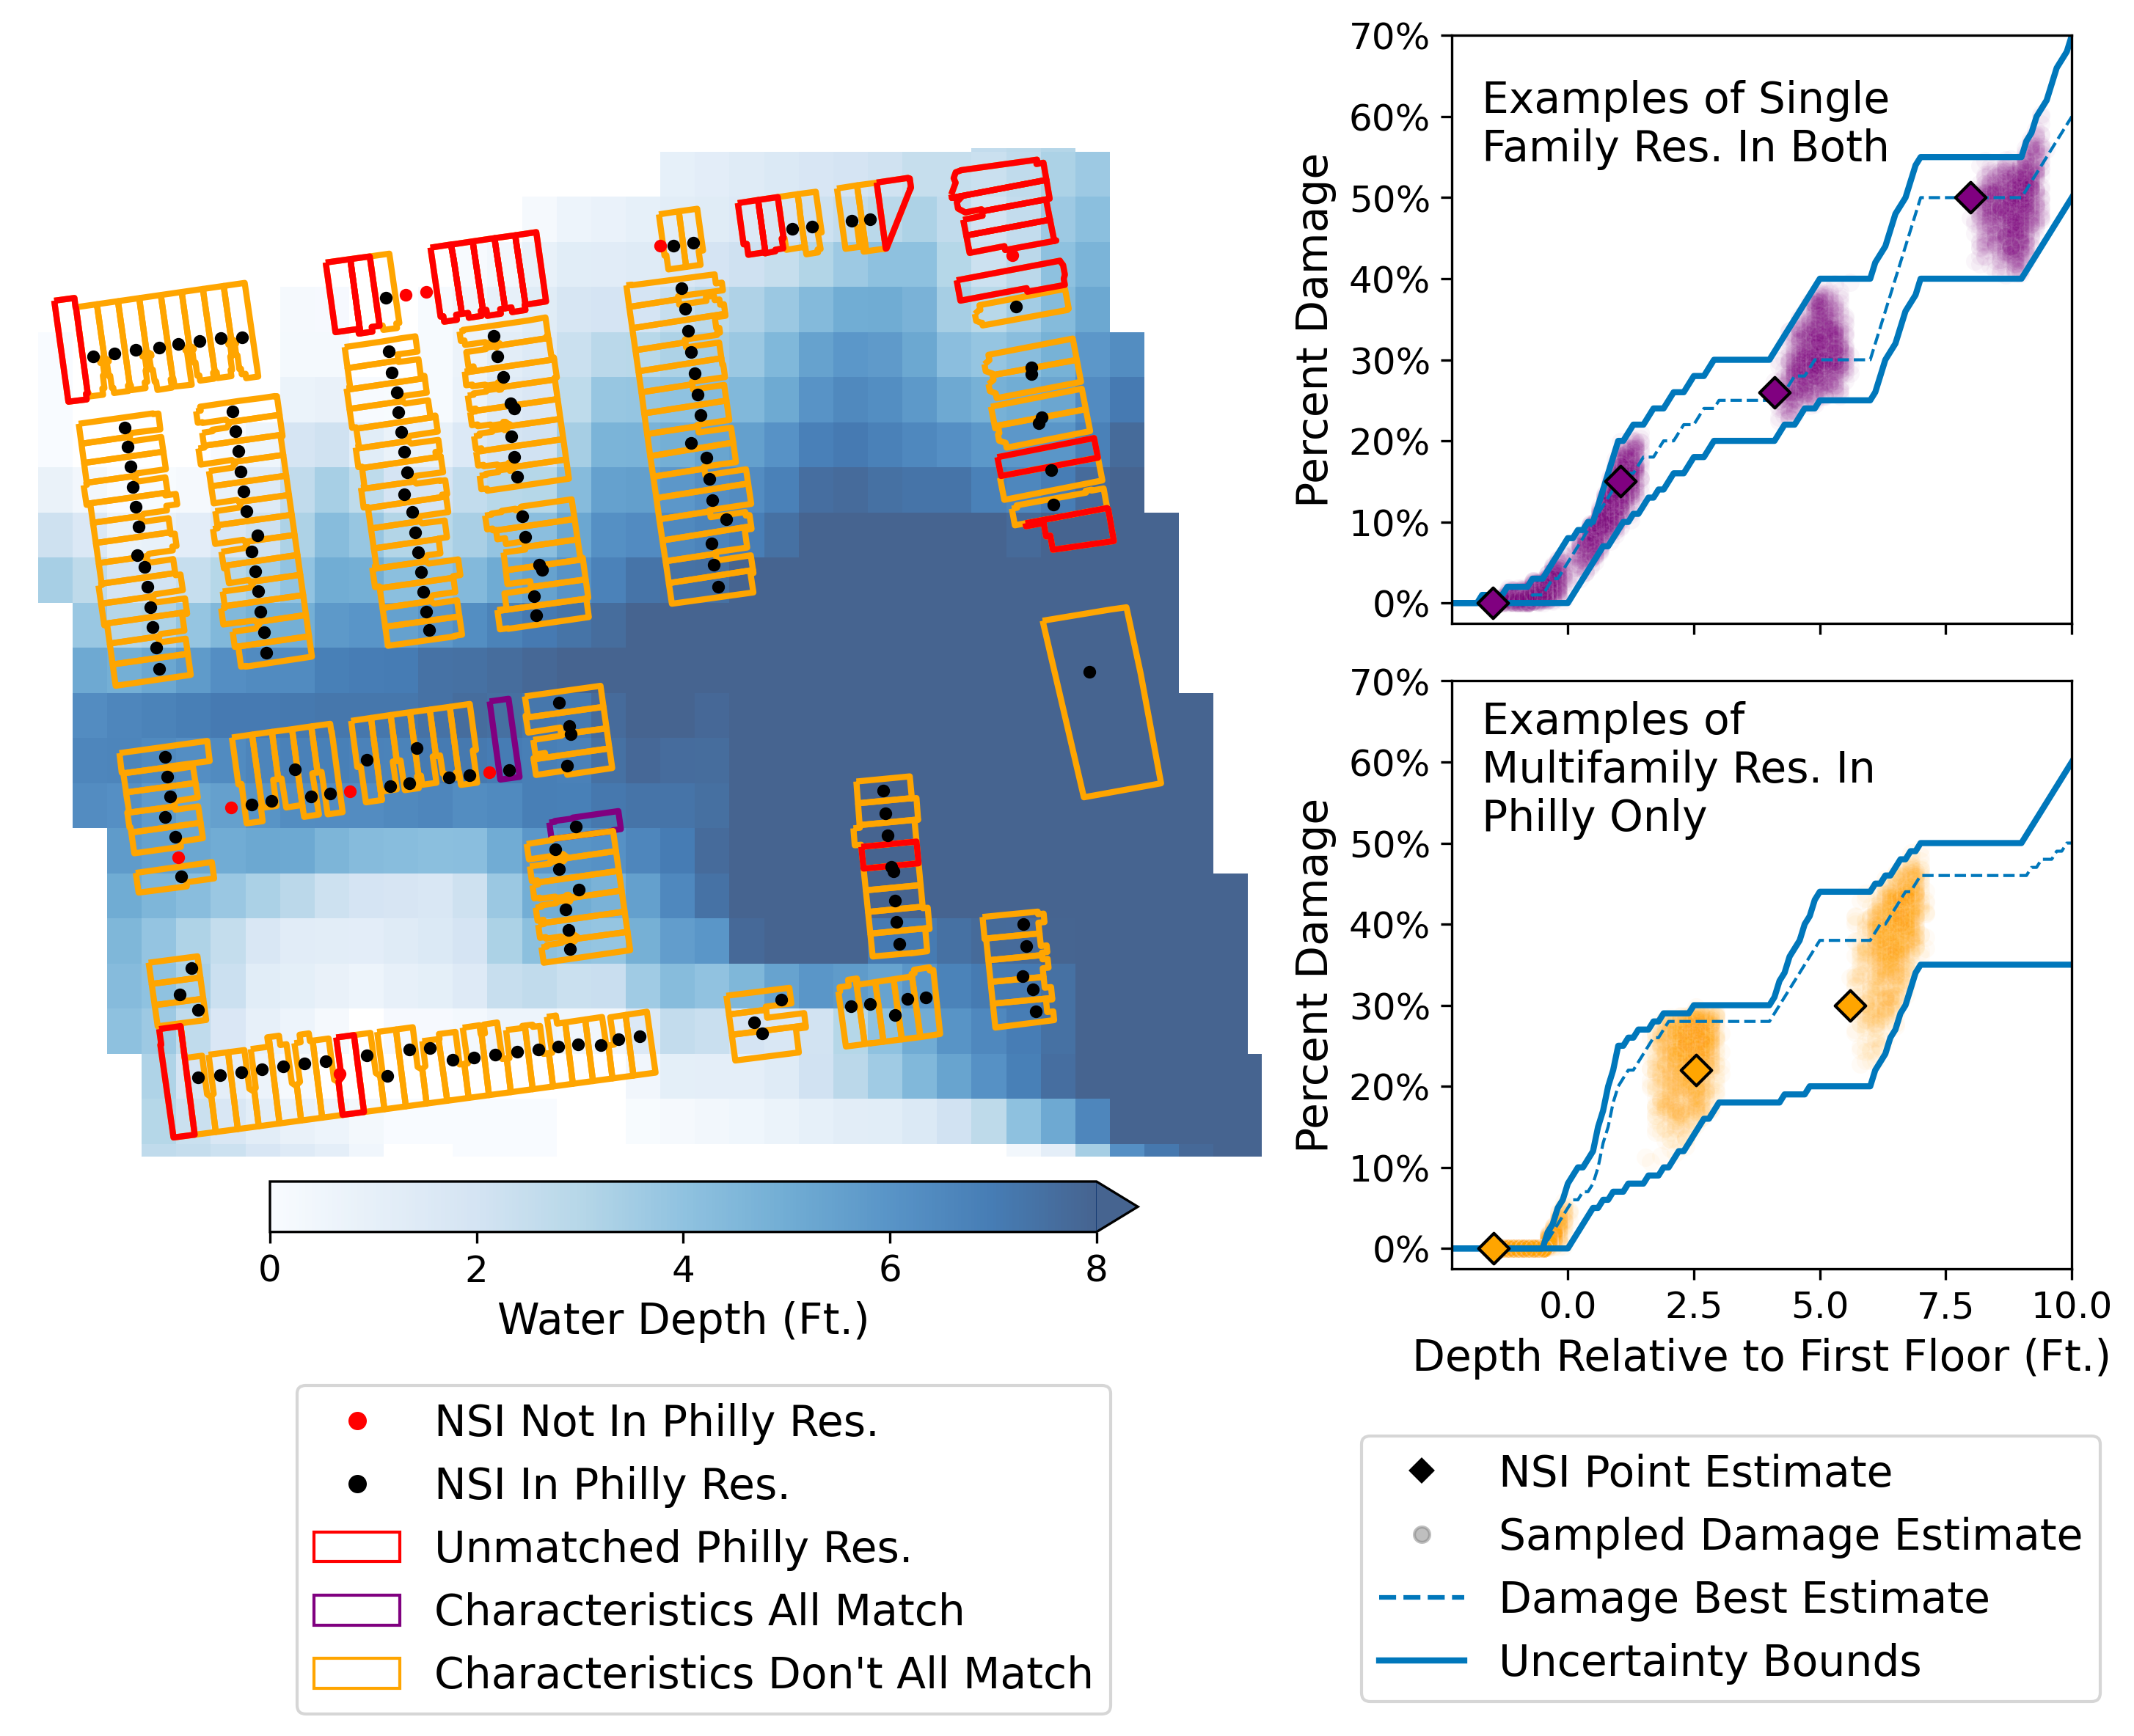

In [119]:
# Create figure with custom grid layout
fig = plt.figure(figsize=(10, 8), dpi=300)

# Create a 2-row grid with the top row for spatial plot and bottom row for damage functions
# The bottom row will be split into two equal columns
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], width_ratios=[2, 1])

# Create the spatial plot in the top row spanning both columns
ax_spatial = fig.add_subplot(gs[:, 0])

# Create the two damage function plots in the bottom row
ax_match = fig.add_subplot(gs[0, 1])
ax_mismatch = fig.add_subplot(gs[1, 1])

# SPATIAL PLOT CODE
cmap_with_zero = plt.cm.get_cmap('Blues').copy()
cmap_with_zero.set_bad('none')

# Create a mask for zero values
zero_mask = clipped_dg[0] <= 0.01
da_masked = clipped_dg[0].where(~zero_mask)

# Plot the masked data
fg = (da_masked*3.28084).plot(ax=ax_spatial, cmap=cmap_with_zero, alpha=.75,
                              add_colorbar=False,
                              vmin=0, vmax=8)

phil_temp[phil_temp['match'] == 'All'].plot(ax=ax_spatial, lw=2, edgecolor='purple', color='none')
phil_temp[phil_temp['match'] != 'All'].plot(ax=ax_spatial, lw=2, edgecolor='orange', color='none')
phil_temp[phil_temp['match'] == 'Unmatched Philly'].plot(ax=ax_spatial, lw=2, edgecolor='red', color='none')
nsi_temp[nsi_temp['match'] != 'NSI Not In Philly'].plot(ax=ax_spatial, color='black', markersize=10)
nsi_temp[nsi_temp['match'] == 'NSI Not In Philly'].plot(ax=ax_spatial, color='red', markersize=10)

ax_spatial.axis('off')
# ax_spatial.set_title('Spatial Distribution of\nBuildings and Flood Depths', size=16, pad=15)
ax_spatial.set_title('')

ax_spatial.set_xlim([-.0087-7.522e1, -.00538-7.522e1])
ax_spatial.set_ylim([39.96928, 39.97135])

# cx.add_basemap(ax_spatial,
#                source=cx.providers.Esri.WorldImagery,
#                attribution=False,
#                crs=phil_temp.crs)

cbax = ax_spatial.inset_axes([0.2, -0.075, 0.7, 0.05])

fig.colorbar(fg,
             ax=ax_spatial,
             cax=cbax,
             orientation='horizontal',
             # shrink=.8,
             # anchor=(.8, .9),
             # pad=.05,
             # fraction=.05
             extend='max',
             label='Water Depth (Ft.)')
fg.colorbar.ax.tick_params(labelsize=12)
fg.colorbar.set_label(label='Water Depth (Ft.)',
                     size=14)

# Spatial plot legend
spatial_legend_elements = [
    Line2D([0], [0], marker='o', ls='',
          color='red',
          label='NSI Not In Philly Res.',
          markerfacecolor='red',
          markersize=5),
    Line2D([0], [0], marker='o', ls='',
          color='black',
          label='NSI In Philly Res.',
          markerfacecolor='black',
          markersize=5),
    Patch(facecolor='none', edgecolor='red',
         label='Unmatched Philly Res.'),
    Patch(facecolor='none', edgecolor='purple',
         label='Characteristics All Match'),
    Patch(facecolor='none', edgecolor='orange',
         label='Characteristics Don\'t All Match')
]

# Position the spatial legend at the bottom of the spatial plot
ax_spatial.legend(handles=spatial_legend_elements,
                 loc='center',
                 fontsize=14,
                 bbox_to_anchor=(0.55, -0.39),
                 ncol=1)

# DAMAGE FUNCTION PLOTS

# Define variables and data
bfids = [30280, 36606, 31545, 34756]
bfids_m = [60382, 19357, 34418]

# Plot for matched buildings
naccs_2snb.plot(x='depth_ft',
               y='mid',
               ax=ax_match,
               lw=1,
               ls='dashed',
               color='#0077BB')

for y_name in ['low', 'high']:
    naccs_2snb.plot(x='depth_ft',
                   y=y_name,
                   ax=ax_match,
                   lw=2,
                   ls='solid',
                   color='#0077BB')

for i, bfid in enumerate(bfids):
    nsi_ffe = main_nsi[main_nsi['bfid'] == bfid]['found_ht'].values[0]
    nsi_d = main_nsi[main_nsi['bfid'] == bfid][dg_id].values[0]
    nsi_rel = main_nsi[main_nsi['bfid'] == bfid]['rel_loss'].values[0]
    nsi_d_adj = nsi_d - nsi_ffe
    
    phil_bfid_plot = main_phil[main_phil['bfid'] == bfid]
    phil_bfid_plot['d_adj'] = phil_bfid_plot[dg_id] - phil_bfid_plot['ffe']
    
    sns.scatterplot(data=phil_bfid_plot,
                   x='d_adj',
                   y='rel_loss',
                   color='purple',
                   ax=ax_match,
                   alpha=.035,)
    ax_match.scatter(nsi_d_adj,
                    y=nsi_rel,
                    s=50,
                    marker='D',
                    color='purple',
                    zorder=3,
                    edgecolor='black')

# Plot for mismatched buildings
naccs_3snb.plot(x='depth_ft',
               y='mid',
               ax=ax_mismatch,
               lw=1,
               ls='dashed',
               color='#0077BB')

for y_name in ['low', 'high']:
    naccs_3snb.plot(x='depth_ft',
                   y=y_name,
                   ax=ax_mismatch,
                   lw=2,
                   ls='solid',
                   color='#0077BB')

for i, bfid in enumerate(bfids_m):
    nsi_ffe = main_nsi[main_nsi['bfid'] == bfid]['found_ht'].values[0]
    nsi_d = main_nsi[main_nsi['bfid'] == bfid][dg_id].values[0]
    nsi_rel = main_nsi[main_nsi['bfid'] == bfid]['rel_loss'].values[0]
    nsi_d_adj = nsi_d - nsi_ffe
    
    phil_bfid_plot = main_phil[main_phil['bfid'] == bfid]
    phil_bfid_plot['d_adj'] = phil_bfid_plot[dg_id] - phil_bfid_plot['ffe']
    
    sns.scatterplot(data=phil_bfid_plot,
                   x='d_adj',
                   y='rel_loss',
                   color='orange',
                   ax=ax_mismatch,
                   alpha=.035,)
    ax_mismatch.scatter(nsi_d_adj,
                       y=nsi_rel,
                       s=50,
                       marker='D',
                       color='orange',
                       zorder=3,
                       edgecolor='black')

# Configure both damage function plots
for ax, title in zip([ax_match, ax_mismatch], 
                     ['Examples Of Depth\nDamage Function Match', 
                      'Examples Of Depth\nDamage Function Mismatch']):
    ax.set_ylim([-.025, .7])
    xlow = naccs_2snb[naccs_2snb['high'] == 0]['depth_ft'].max() - .5
    xhigh = naccs_2snb['depth_ft'].max()
    
    # Remove auto-generated legends
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    
    ax.set_xlim([xlow, xhigh])
    # ax.set_title(title, size=14)

ax_mismatch.set_xlabel('Depth Relative to First Floor (Ft.)', size=14)
ax_mismatch.tick_params('both', labelsize=12)
ax_match.tick_params('y', labelsize=12)
ax_match.set_xlabel('')
ax_match.tick_params('x', which='both', labelbottom=False)

# Only set y-label on the left plot
ax_match.set_ylabel('Percent Damage', size=14)
ax_mismatch.set_ylabel('Percent Damage', size=14)
ax_match.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, symbol='%', decimals=0))
ax_mismatch.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, symbol='%', decimals=0))

# Remove y-tick labels from right plot
# ax_mismatch.tick_params(axis='y', which='both', labelleft=False)

# Create legend for damage function plots
damage_legend_elements = [
    Line2D([0], [0], marker='D', ls='',
          color='black',
          label='NSI Point Estimate',
          markerfacecolor='black',
          markersize=5),
    Line2D([0], [0], marker='o', ls='',
          color='gray',
          alpha=.5,
          label='Sampled Damage Estimate',
          markerfacecolor='gray',
          markersize=5),
    Line2D([0], [0], marker='', ls='--',
          color='#0077BB',
          alpha=1,
          label='Damage Best Estimate'),
    Line2D([0], [0], marker='', ls='-',
          lw=2,
          color='#0077BB',
          alpha=1,
          label='Uncertainty Bounds'),
]

# Add the damage function legend between the two bottom plots
ax_mismatch.legend(handles=damage_legend_elements,
          loc='center',
          ncol=1,
          fontsize=14,
          bbox_to_anchor=(0.45, -0.51))

# Add annotations
ax_match.annotate('Examples of Single\nFamily Res. In Both',
                 xy=(-1.7, .59),
                 xycoords='data',
                 horizontalalignment='left',
                 verticalalignment='center',
                 size=14)

ax_mismatch.annotate('Examples of\nMultifamily Res. In\nPhilly Only',
                    xy=(-1.7, .59),
                    xycoords='data',
                    horizontalalignment='left',
                    verticalalignment='center',
                    size=14)

# Adjust layout
plt.tight_layout()

fig.savefig(join(FIG_DIR, 'fig1.png'), dpi=300, bbox_inches='tight')

### Figure 2
Damage discrepancies across structure inventories by match type and flood depth. Panel A shows the distribution of differences between deterministic National Structure Inventory (NSI) damage estimates and the mean of the Philadelphia ensemble damage estimates. The red diamonds indicate the mean for each match type and flood depth subgroup. Panel B shows the count of each match type for each flood depth subgroup. Panel C shows the mean cumulative damage discrepancy across the ensemble over depths for each match type and in aggregate. 

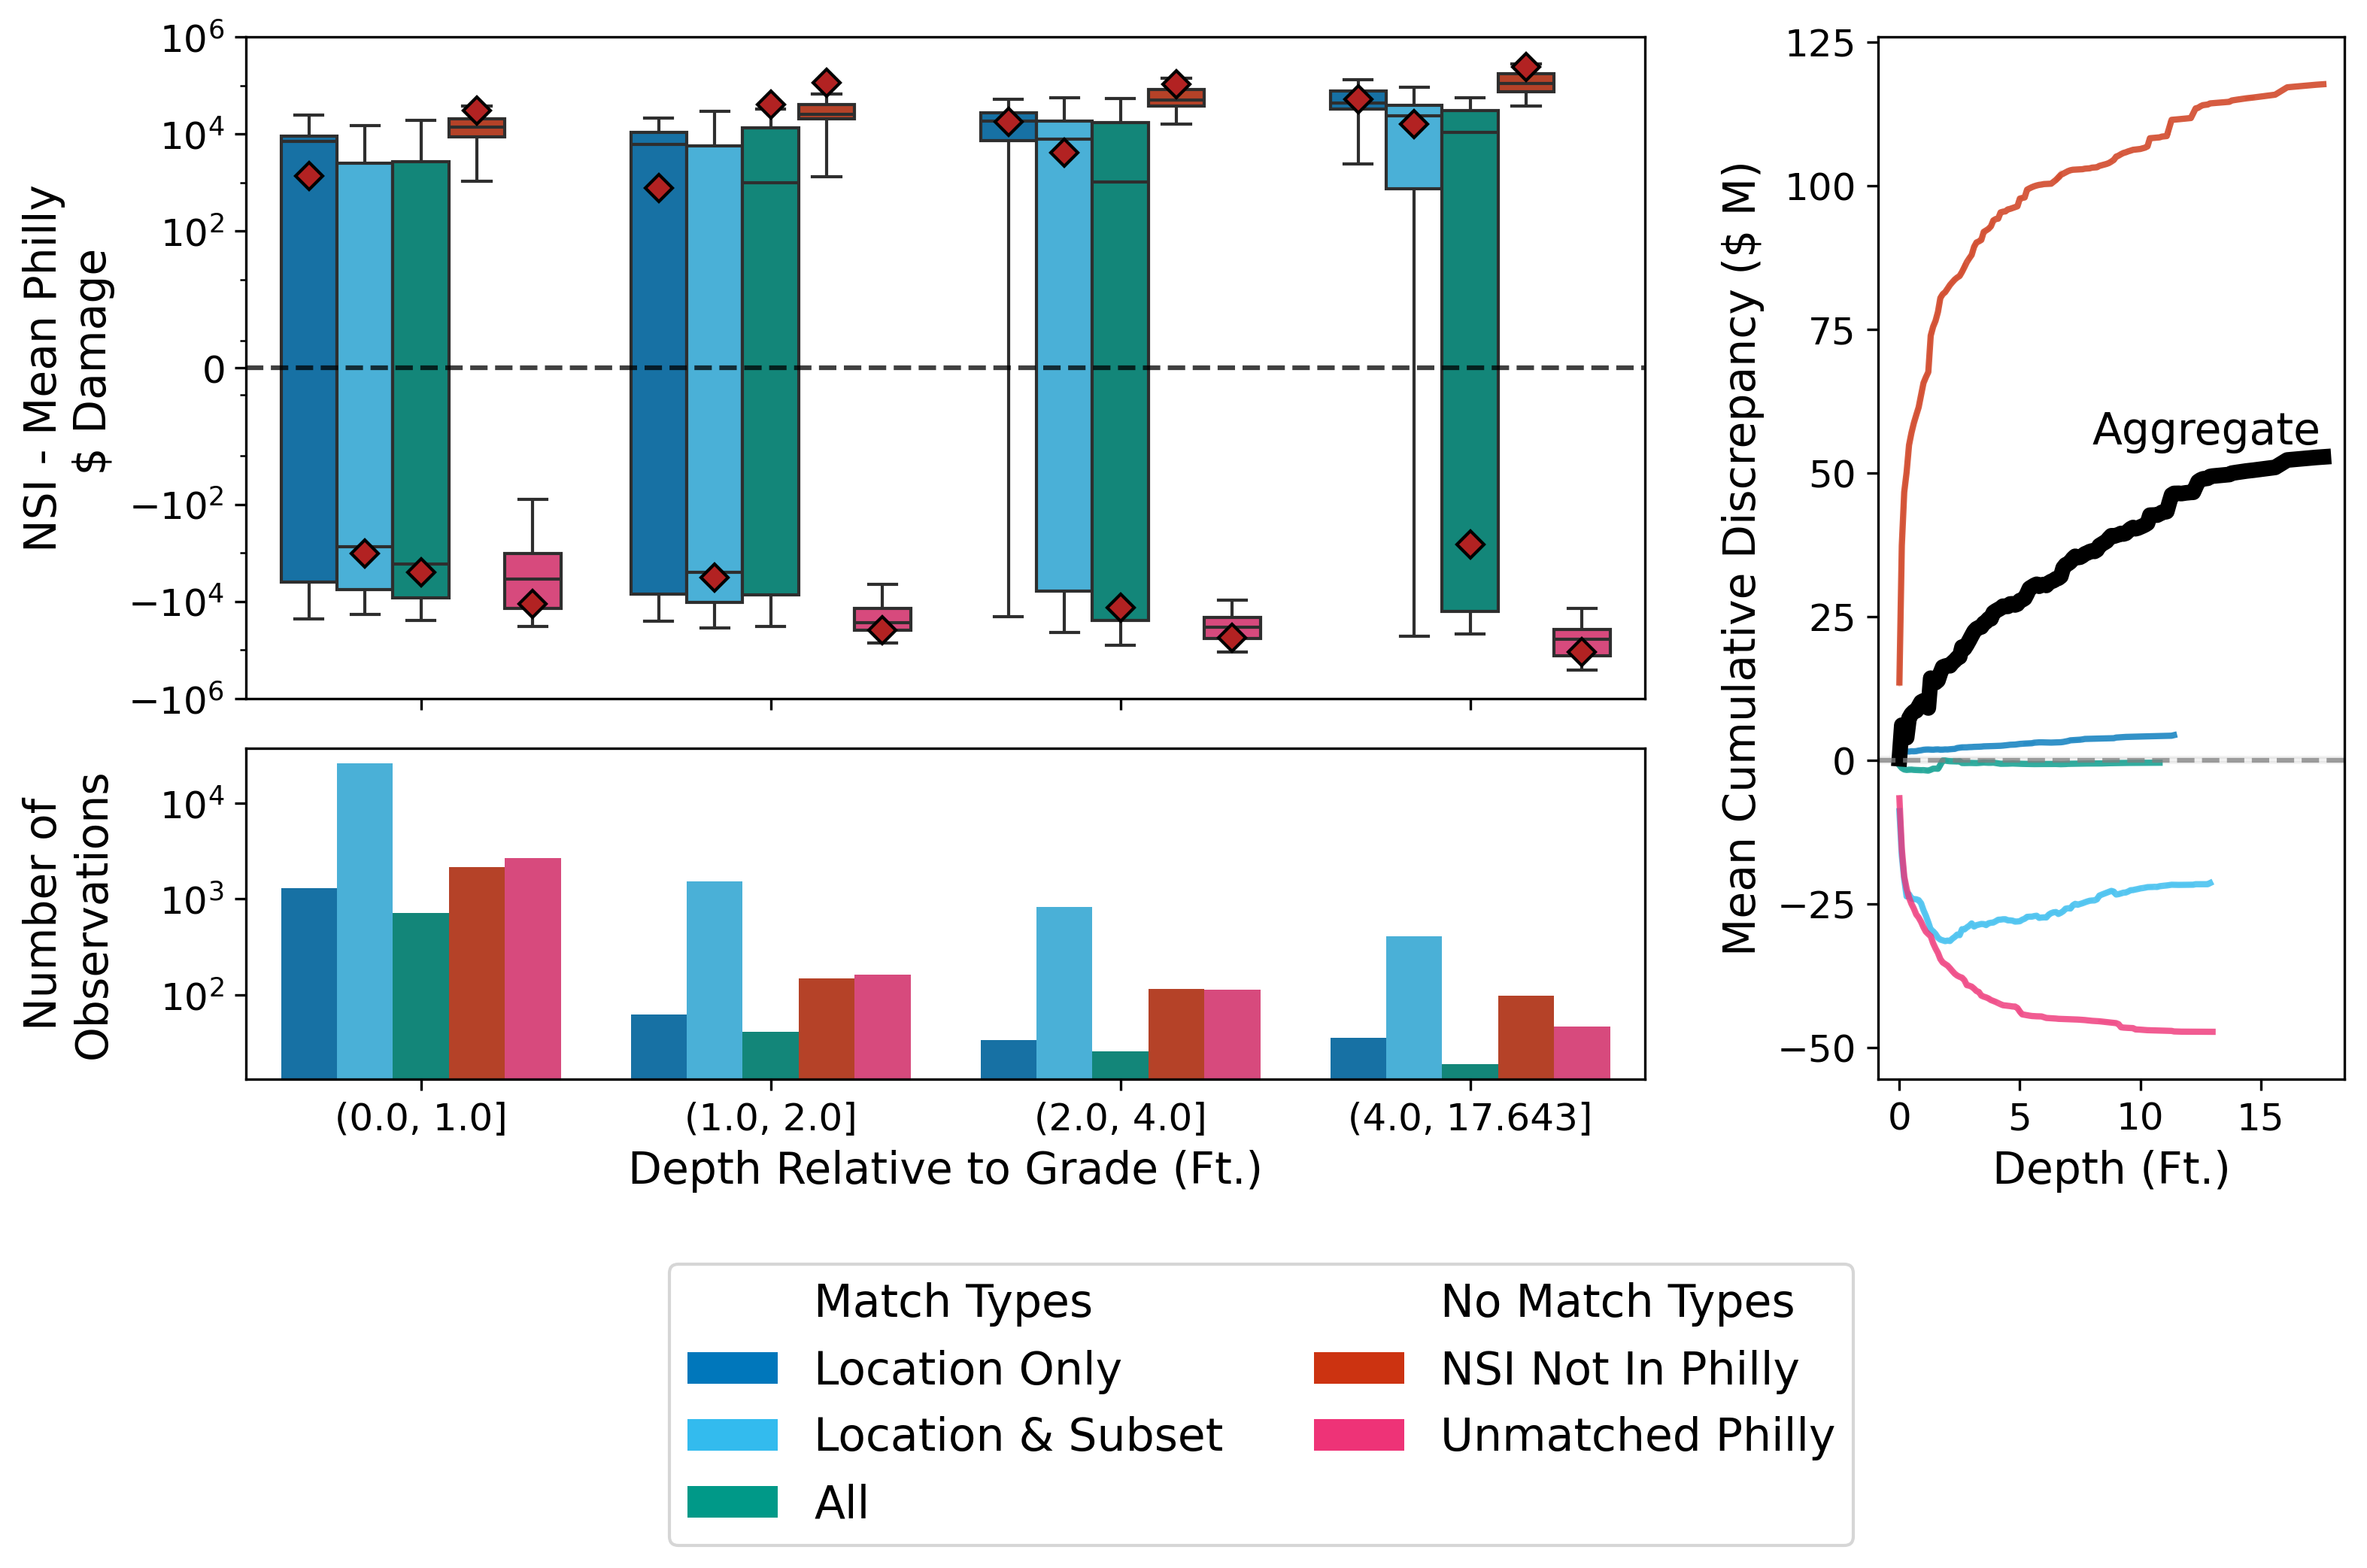

In [126]:
# Define consistent order for better visual alignment
hue_order = ['Location Only',
             'Location & Subset',
             'All',
             'NSI Not In Philly',
             'Unmatched Philly']

# Define a colormap that groups matches and non matches together thematically
palette_dict = {'Location Only': '#0077BB',
                'Location & Subset': '#33BBEE',
                'All': '#009988',
                'NSI Not In Philly': '#CC3311',
                'Unmatched Philly': '#EE3377'}

# Create figure with custom grid layout
fig = plt.figure(figsize=(12, 6), dpi=300)
gs = gridspec.GridSpec(2, 2, height_ratios=[2, 1],
                       width_ratios=[3, 1],
                       wspace=.25,
                       hspace=0.1)

# Left column - original 3×1 layout
ax1 = fig.add_subplot(gs[0, 0])  # Top - absolute difference
ax2 = fig.add_subplot(gs[1, 0])  # Bottom - counts
ax4 = fig.add_subplot(gs[:, 1])

# First create the depth bins if not already done
test_gb['depth_bins'] = pd.cut(test_gb['depth_ft'],
                              bins=[0, 1, 2, 4, test_gb['depth_ft'].max()])
test_gb['diff_thou'] = test_gb['diff']/1e3

# Top: Absolute difference boxplot
sns.boxplot(data=test_gb,
           x='depth_bins',
           y='diff',
           hue='Matches',
           hue_order=hue_order,
           palette=palette_dict,
           showfliers=False,
           showmeans=True,
           meanprops={'markerfacecolor': 'firebrick',
                      'markeredgecolor': 'black', 'marker': 'D'},
           legend=True,
           ax=ax1)

ax1.axhline(0, color='black', ls='--', alpha=.75)
ax1.set_xlabel('')  # Remove x-label as it's shared
ax1.set_ylabel('NSI - Mean Philly\n $ Damage', size=14)
ax1.set_yscale('symlog')
ax1.set_ylim([-10e5, 10e5])
ax1.set_yticks([-1e6, -1e4, -1e2, 0, 1e2, 1e4, 1e6])
# Remove x-tick labels for middle row
ax1.set_xticklabels([])

# Bottom: Count plot
sns.countplot(data=test_gb,
             x='depth_bins',
             hue='Matches',
             hue_order=hue_order,
             palette=palette_dict,
             legend=False,
             ax=ax2)

ax2.set_yscale('log')
ax2.minorticks_off()
ax2.set_xlabel('Depth Relative to Grade (Ft.)', size=14)
ax2.set_ylabel('Number of\nObservations', size=14)


# Align y-labels
fig.align_ylabels([ax1, ax2])

# Panel 4: Cumulative discrepancy plot (right side)
# Let seaborn handle the categories directly
sns.lineplot(data=test_gb,
            x='depth_plot',
            y='cm_diff',
            hue='Matches',
            hue_order=hue_order,
            palette=palette_dict,
            ax=ax4,
            alpha=0.8,
            legend=False,
            linewidth=2)

# Add the overall discrepancy line with enhanced styling
sns.lineplot(data=test_gb,
            x='depth_plot',
            y='cm_diff_agg',
            color='black',
            lw=5,
            label='Overall Discrepancy',
            legend=False,
            ax=ax4)

# Improve the cumulative plot styling
ax4.axhline(0, color='gray', ls='--', alpha=.75, linewidth=1.5)
ax4.set_ylabel('Mean Cumulative Discrepancy ($ M)', size=14)
ax4.set_xlabel('Depth (Ft.)', size=14)
# ax4.axvline(1, color='black', linestyle='--', alpha=.3)

# Add a shaded region around the zero line to emphasize the crossing points
ax4.axhspan(-0.5, 0.5, color='gray', alpha=0.1)

# Optimize legend placement - centered at bottom
# handles, labels = ax1.get_legend_handles_labels()
ax1.legend_.remove()  # Remove the original legend

legend_elements = [Patch(facecolor='none', edgecolor='none',
                         label='Match Types'),
                   Patch(facecolor=palette_dict['Location Only'],
                         label='Location Only'),
                   Patch(facecolor=palette_dict['Location & Subset'],
                         label='Location & Subset'),
                   Patch(facecolor=palette_dict['All'],
                         label='All'),
                   Patch(facecolor='none', edgecolor='none',
                         label='No Match Types'),
                   Patch(facecolor=palette_dict['NSI Not In Philly'],
                         label='NSI Not In Philly'),
                   Patch(facecolor=palette_dict['Unmatched Philly'],
                         label='Unmatched Philly'),]

legend = fig.legend(handles=legend_elements,# handles, labels,
                    # title='Location and Characteristic Matches',
                    title_fontsize='x-large',
                    fontsize='x-large', 
                    loc='upper center',
                    bbox_to_anchor=(0.5, -0.01), 
                    ncol=2) 


# Add the annotation label
ax4.annotate('Aggregate', 
            xy=(8, 55),  # Point to annotate
            fontsize=14)

# Adjust tick sizes
for ax in [ax1, ax2, ax4]:
    ax.tick_params(labelsize=12)

fig.savefig(join(FIG_DIR, 'fig2.png'), bbox_inches='tight', dpi=300)

### Figure 3
Comparison of damage estimates for matched structures at different depths. The rows show a different matched structure (i.e., structures with the same location, number of stories, and basement type) across inventories. From left to right, the columns show percent damage to a structure, structure value, and structure damage. Blue histograms represent the Philadelphia ensemble, which accounts for uncertainty in both first-floor elevation and depth-damage functions (DDF). Red vertical lines indicate deterministic National Structure Inventory (NSI) estimates, which do not account for DDF uncertainty. Orange histograms represent the NSI inventory accounting for DDF uncertainty but not in first-floor elevation. Box plots above each histogram summarize the distributions of the ensemble members, with diamonds denoting ensemble means. 

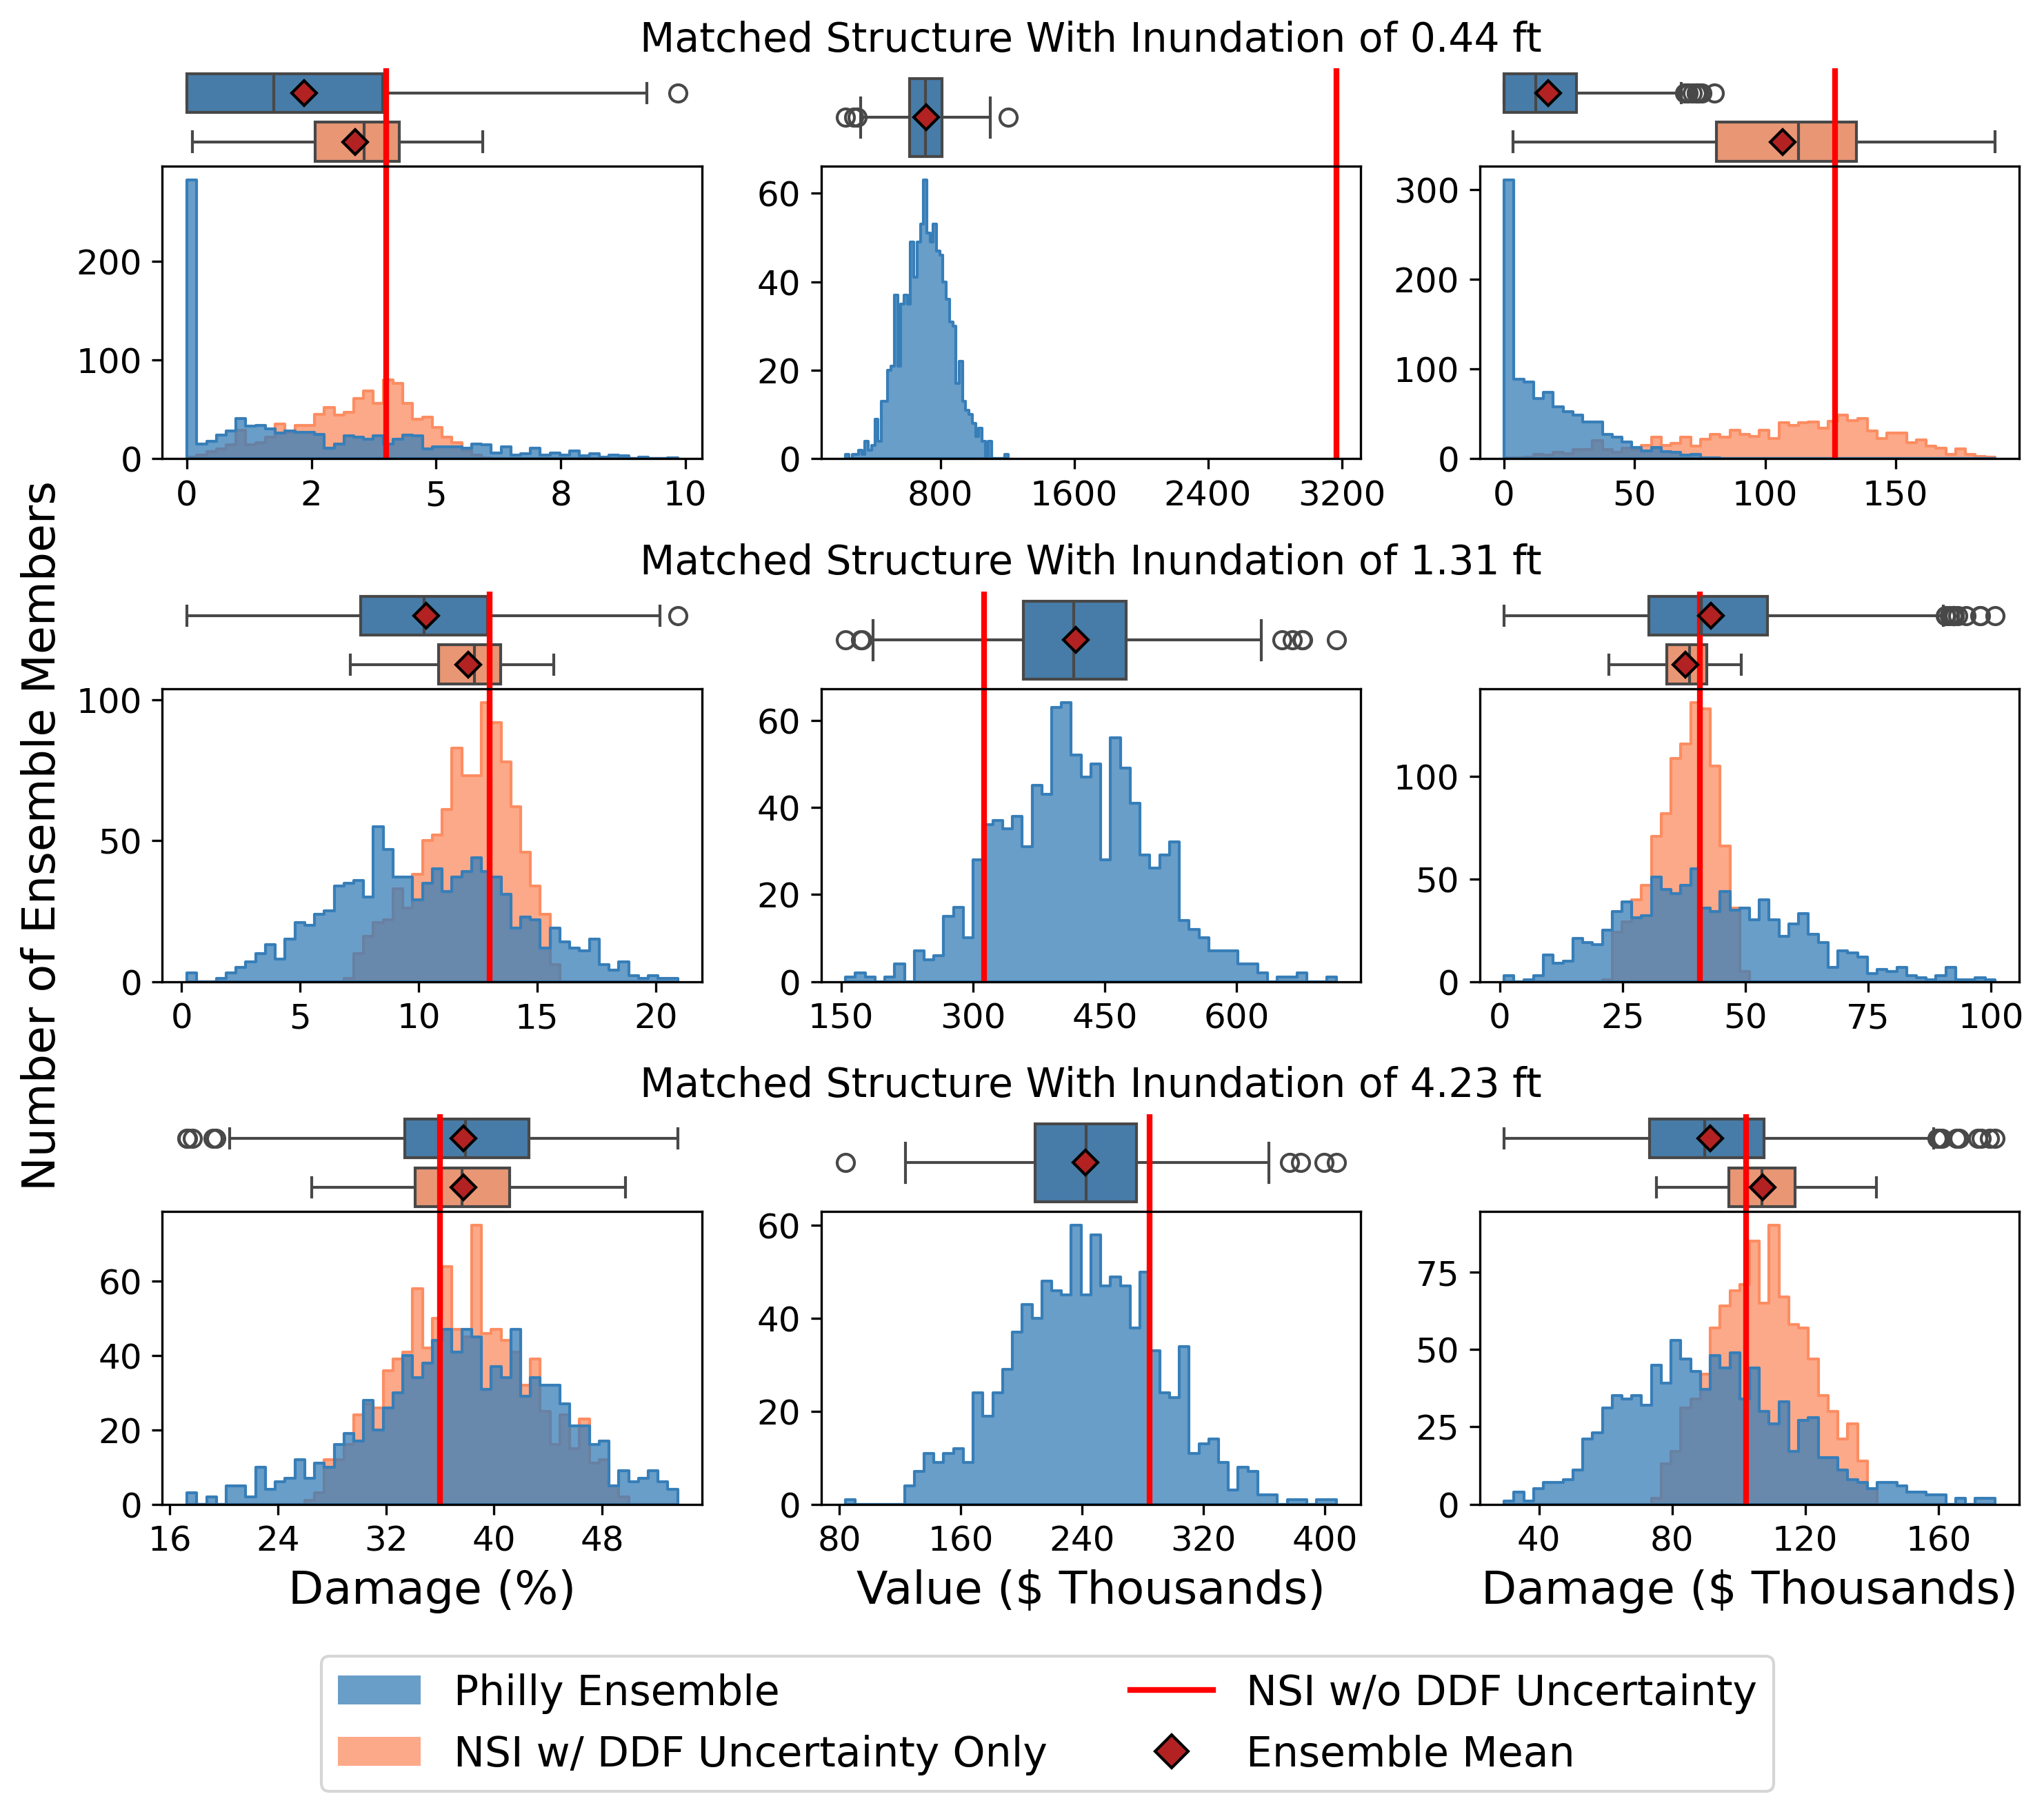

In [170]:
def plot_building_damage_comparison(phil_data, nsi_data, ens_comp, bfids,
                                   depth_col='depth_ft',
                                   n_bins=50,
                                   dam_cols=['rel_loss', 'val_s', 'loss'],
                                   dam_labels=['Damage (%)', 'Value ($ Thousands)', 'Damage ($ Thousands)'],
                                   scale_factors=[1, 1e3, 1e3],
                                   phil_label='Philly Ensemble',
                                   ens_label='Alternate Ensemble'):
    """
    Create a generalized comparison of building damages between Philadelphia and NSI data.
    
    Parameters:
    -----------
    phil_data : DataFrame
        Philadelphia building data with damage columns
    nsi_data : DataFrame
        NSI building data with damage columns
    ens_comp : DataFrame
        Second ensemble data to compare with Philadelphia
    bfids : list
        List of building IDs to analyze
    depth_col : str
        Name of the column containing depth information
    n_bins: int
        Number of bins for histogram
    dam_cols : list
        List of damage column names to compare
    dam_labels : list
        Labels for the damage columns
    scale_factors : list
        Scaling factors for the damage values
    phil_label : str
        Label for the Philadelphia ensemble
    ens_label : str
        Label for the second ensemble
    """
    # Create figure with a grid layout
    fig = plt.figure(figsize=(10, 8), dpi=300)
    
    # Define colors for consistency
    philly_color = sns.color_palette('Set1')[1]
    ens_color = sns.color_palette('Set2')[1]
    nsi_color = 'red'
    
    # Process each building
    for i, bfid in enumerate(bfids):
        # Filter data for this building
        phil_plot = phil_data[phil_data['bfid'] == bfid]
        nsi_plot = nsi_data[nsi_data['bfid'] == bfid]
        ens_plot = ens_comp[ens_comp['bfid'] == bfid]
        
        # Get depth directly from the data
        depth = phil_plot[depth_col].iloc[0]  # Use Philadelphia data for depth
        
        # Process each damage column
        for j, (dam_col, dam_label, scale_factor) in enumerate(zip(dam_cols, dam_labels, scale_factors)):
            # Calculate subplot position
            subplot_idx = i * len(dam_cols) + j + 1
            
            # Create a subplot with 2 rows (boxplot on top, histogram below)
            ax = plt.subplot(len(bfids), len(dam_cols), subplot_idx)
            
            # Create a gridspec for this subplot to have boxplot on top and histogram below
            gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=ax.get_subplotspec(),
                                                 height_ratios=[1, 3], hspace=0)
            
            # Create the boxplot axes (top) and histogram axes (bottom)
            ax_box = fig.add_subplot(gs[0])
            ax_hist = fig.add_subplot(gs[1], sharex=ax_box)
            
            # Hide the main axes
            ax.axis('off')
            
            # Prepare data from both ensembles
            phil_values = (phil_plot.groupby(['sow_ind'])[[dam_col]].sum()/scale_factor).reset_index()[dam_col]
            ens_values = (ens_plot.groupby(['sow_ind'])[[dam_col]].sum()/scale_factor).reset_index()[dam_col]
            
            # Create combined DataFrame for seaborn
            if dam_col != 'val_s':
                combined_data = pd.DataFrame({
                    'value': pd.concat([phil_values, ens_values]),
                    'source': [phil_label] * len(phil_values) + [ens_label] * len(ens_values)
                })
            else:
                combined_data = pd.DataFrame({
                    'value': phil_values,
                    'source': [phil_label] * len(phil_values)
                })
            
            # Create histograms using seaborn
            sns.histplot(data=combined_data, x='value', hue='source', 
                        bins=n_bins, alpha=0.75, ax=ax_hist,
                        palette={phil_label: philly_color, ens_label: ens_color},
                        legend=False,
                        element="step", fill=True, stat="count")
            
            # Create boxplots using seaborn
            sns.boxplot(data=combined_data, x='value', y='source', 
                       orient='h', ax=ax_box,
                       hue='source',
                       legend=False,
                       palette={phil_label: philly_color, ens_label: ens_color},
                       showmeans=True,
                       meanprops={'markerfacecolor': 'firebrick',
                                 'markeredgecolor': 'black',
                                 'marker': 'D'})
            
            # Remove y-axis labels but keep the ticks for visual separation
            ax_box.set_yticklabels([])
            ax_box.set_yticks([])
            ax_box.set_xlabel('')
            ax_box.axis('off')  # Hide the boxplot axes
            
            # Add NSI reference line
            nsi_value = nsi_plot[dam_col].sum()/scale_factor
            ax_hist.axvline(nsi_value, color=nsi_color, linestyle='-', linewidth=2)
            ax_box.axvline(nsi_value, color=nsi_color, linestyle='-', linewidth=2)
            
            # Configure histogram
            ax_hist.grid(False)
            if i == len(bfids) - 1:  # Only add x-label to bottom row
                ax_hist.set_xlabel(dam_label, size=16)
            else:
                ax_hist.set_xlabel('')
            
            if j == 0 and i == 1:  # Only add y-label to first column of first row
                ax_hist.set_ylabel('Number of Ensemble Members', size=16)
            else:
                ax_hist.set_ylabel('')
            
            ax_hist.tick_params(labelsize=12)
            ax_hist.xaxis.set_major_locator(plt.MaxNLocator(5))
            
            # Process the x ticks for % damage
            if j == 0:
                ax_hist.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, symbol=None, decimals=0))
            
            # Remove the automatically generated legend
            if ax_hist.get_legend():
                ax_hist.get_legend().remove()
            
            # Add row title for depth
            # if j == 0:
                # ax.annotate(f"Matched Structure With Inundation of {depth:.2f} ft",
                #            xy=(1.1, 1.05),
                #            horizontalalignment='center',
                #            xycoords='axes fraction',
                #            fontsize=16)
            if j == 1:
                
                ax.set_title(f"Matched Structure With Inundation of {depth:.2f} ft",
                             size=14)

    # Create legend elements
    legend_elements = [
        Patch(facecolor=philly_color, alpha=.75, label=phil_label),
        Patch(facecolor=ens_color, alpha=.75, label=ens_label),
        Line2D([0], [0], color=nsi_color, lw=2, label='NSI w/o DDF Uncertainty'),
        Line2D([0], [0], marker='D', markerfacecolor='firebrick',
              label='Ensemble Mean', ls='', markeredgecolor='black', markersize=8)
    ]
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(wspace=.22, hspace=None)
    
    # Add the legend
    plt.legend(handles=legend_elements,
              fontsize='x-large',
              loc='center',
              bbox_to_anchor=(-.8, -.75),
              frameon=True,
              ncol=2
    )
    
    return fig

# Find bfids from test_gb based on cases you'd like to illustrate
# I want to illustrate that at low depths, you can get large discrepancies
# because of large value disagreements
# I want to illustrate that at moderate depths, you can get small discrepancies
# on average but there is a lot of overlooked uncertainty in status quo and
# just depth-damage function uncertainty approaches
# I want to illustrate that at high depths, the same is true and the uncertainty
# grows
bfids = [6373, 54308, 29903]

ens_comp = all_results['original']['nsi_ddfs:no_adj']
ens_comp['bfid'] = ens_comp['fd_id'].map(fd_bfid_lnk)
ens_comp['rel_loss'] = ens_comp[dam_col]/ens_comp['val_s']
main_nsi['val_s'] = main_nsi['val_struct'].copy()

fig = plot_building_damage_comparison(
    phil_data=main_phil, 
    ens_comp=ens_comp,
    nsi_data=main_nsi, 
    bfids=bfids,
    depth_col=dg_id,
    dam_cols=['rel_loss', 'val_s', dam_col],
    dam_labels= ['Damage (%)', 'Value ($ Thousands)', 'Damage ($ Thousands)'],
    scale_factors=[1, 1000, 1000],
    ens_label='NSI w/ DDF Uncertainty Only'
)

fig.savefig(join(FIG_DIR, 'fig3.png'), bbox_inches='tight', dpi=300)

### Figure 4
Damage discrepancies at census tract scale. Panel A shows mean damage of the Philadelphia ensemble for each census tract. Panel B shows the percent difference between the deterministic NSI-based estimate and the mean damage of the Philadelphia ensemble for each census tract. Panel C shows the rank ordering of census tracts according to both approaches and indicates regions for type 1 and type 2 errors for classifying the top 20th percentile of damage across census tracts. Points are filled with the same hue as Panel B to indicate tract-level discrepancy in percent. The gray line indicates consistent rank ordering across inventories. 

/Users/f006dwr/miniforge3/envs/nsi_fit/lib/python3.12/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)


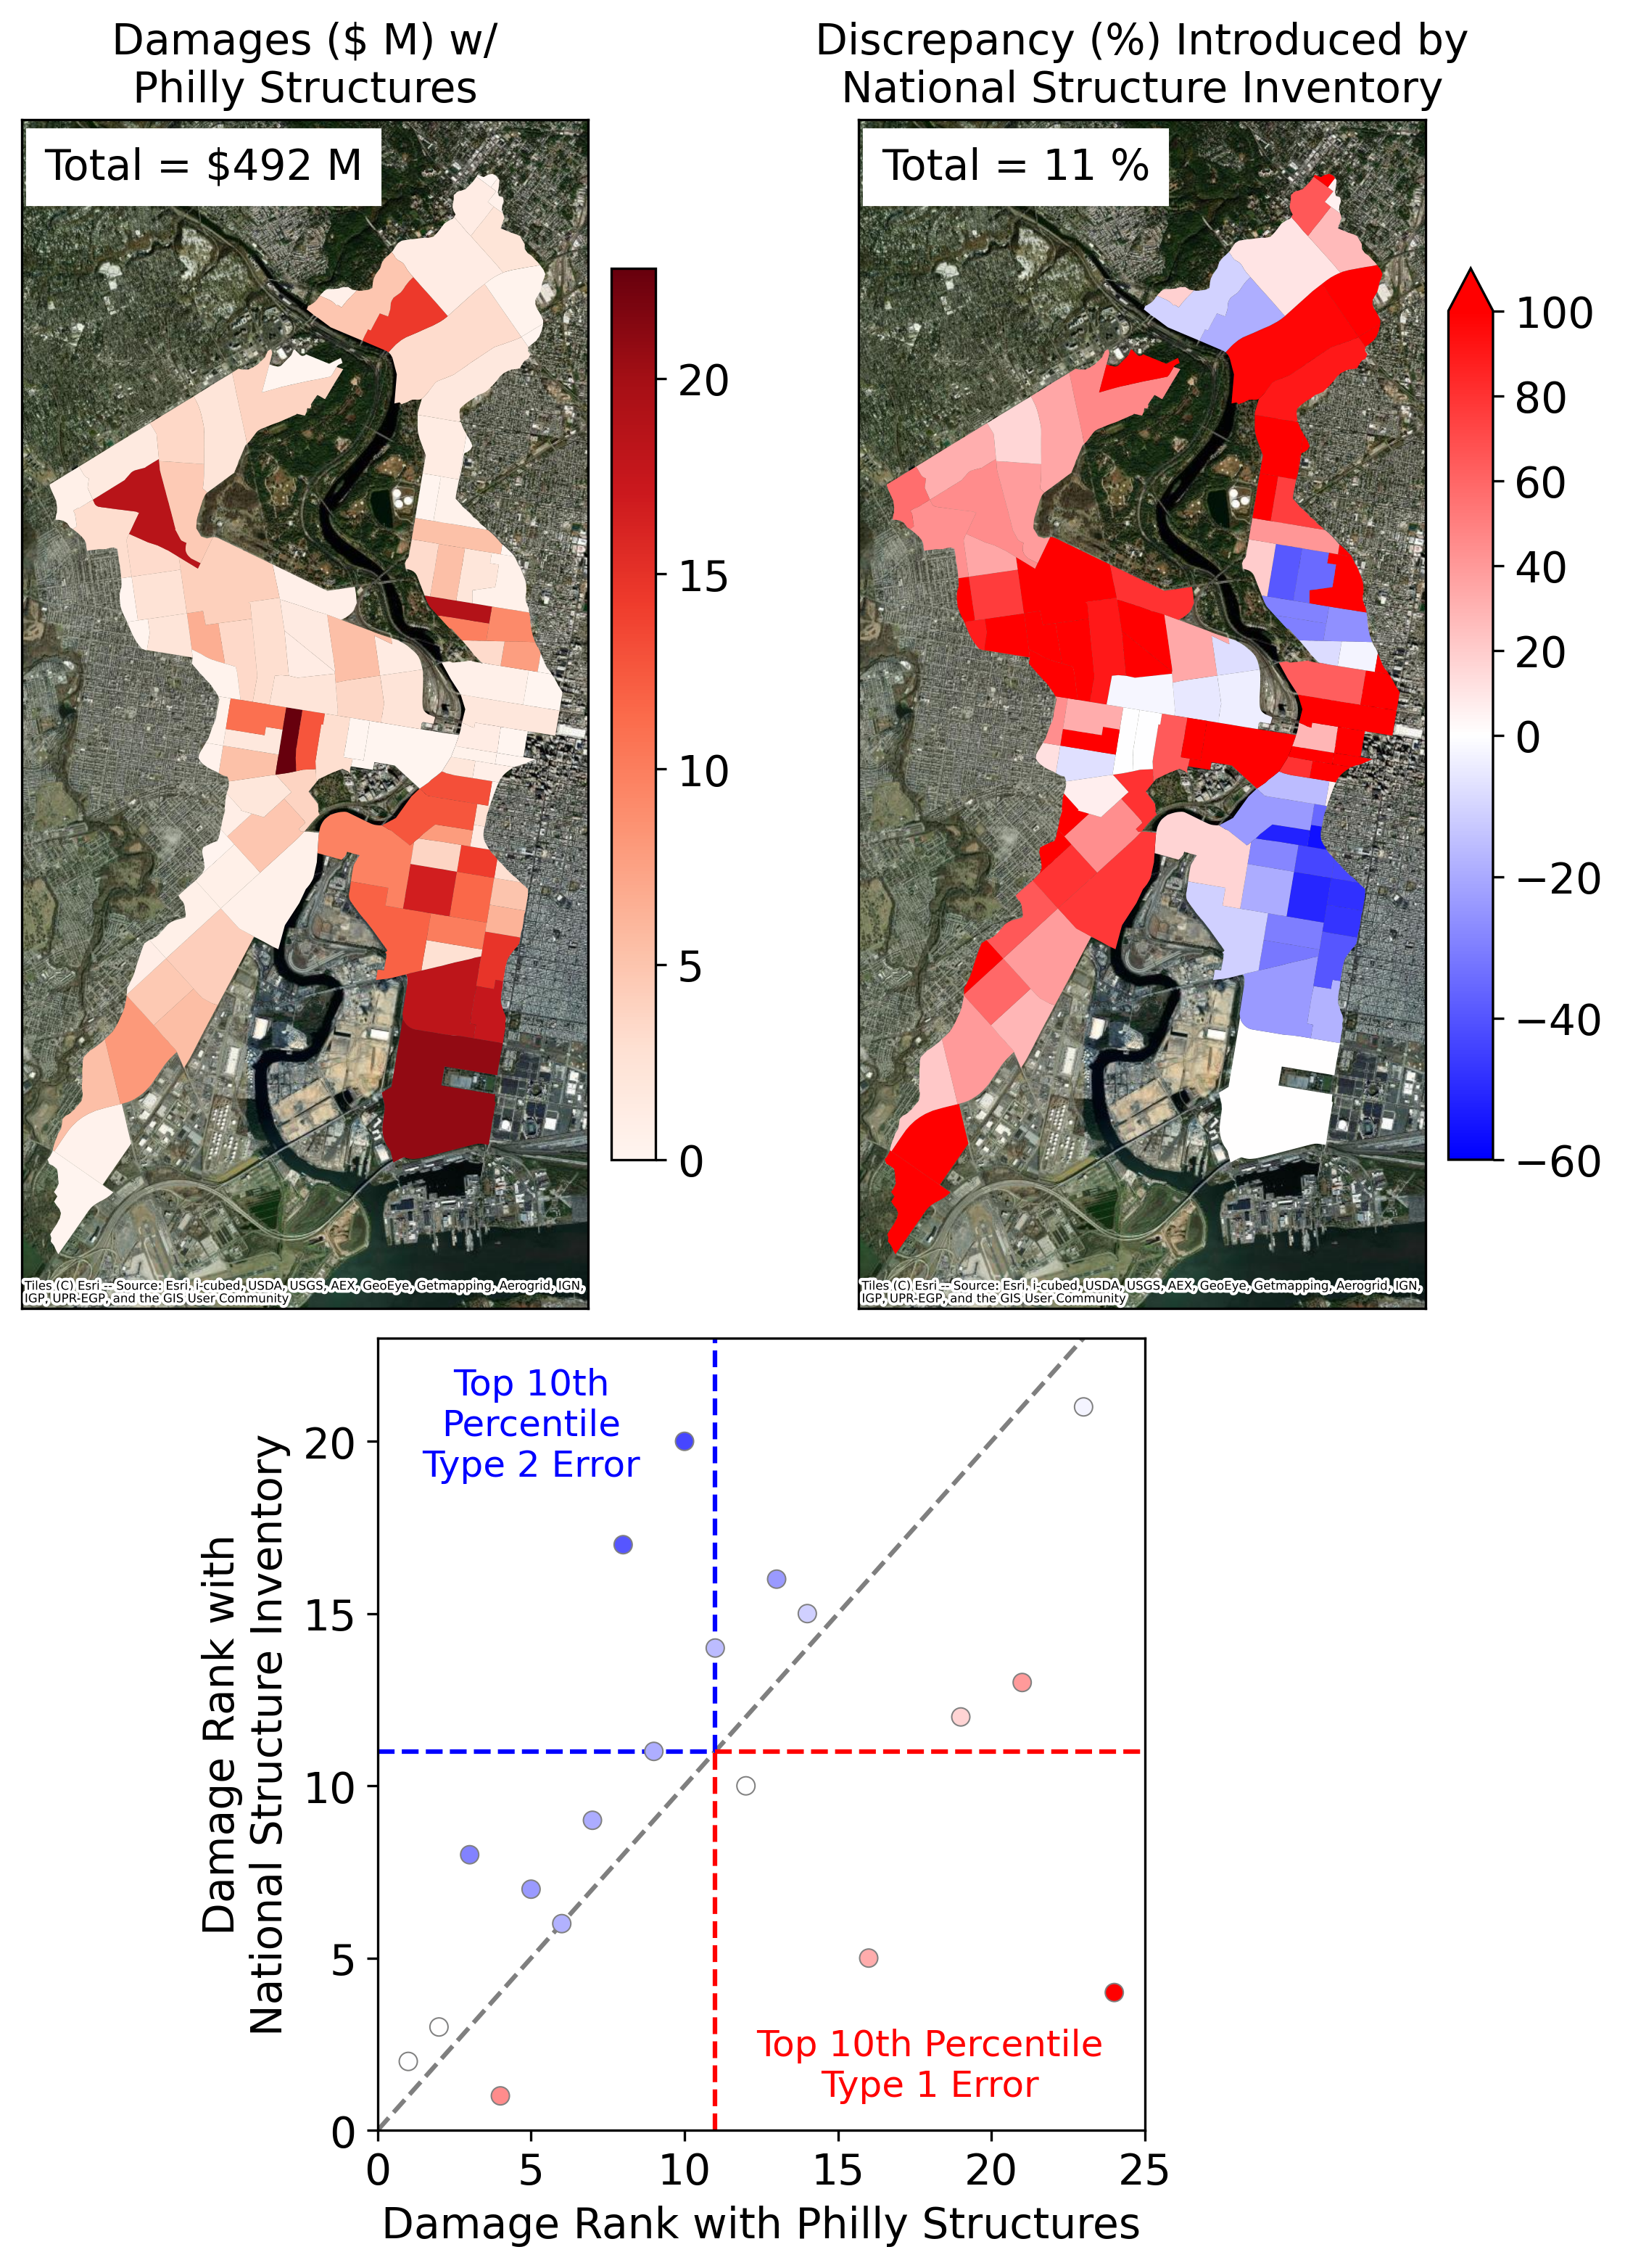

In [178]:
# Create figure
fig = plt.figure(figsize=(12, 12), dpi=300)

# Create two GridSpecs
# Top GridSpec for the maps
gs = gridspec.GridSpec(2, 5, height_ratios=[3, 2],
                       hspace=.03)

# Create axes for maps
ax0 = fig.add_subplot(gs[0, 0:2])
ax1 = fig.add_subplot(gs[0, 2:4])

# Create axes for scatterplot and boxplot
ax3 = fig.add_subplot(gs[1, 1:3])  # Scatterplot

comp_plot = comp_geo.to_crs(epsg=3857)

cmap = 'YlOrRd'

comp_plot['nsi_loss'] = comp_plot[dam_col + '_nsi']/1e6
comp_plot['phil_loss'] = comp_plot[dam_col + '_phil']/1e6

comp_plot['dam_bias'] = comp_plot['nsi_loss'] - comp_plot['phil_loss']
comp_plot['rank_bias'] = (comp_plot['nsi_loss'].rank(ascending=False) -
                          comp_plot['phil_loss'].rank(ascending=False))

comp_plot['dam_pct_bias'] = 100*comp_plot['dam_bias']/comp_plot['phil_loss']+.01

total_nsi_loss = comp_plot['nsi_loss'].sum()
total_phil_loss = comp_plot['phil_loss'].sum()
total_pct_dev = np.round(100*(total_nsi_loss-total_phil_loss)/total_phil_loss)

vmin = min(comp_plot['nsi_loss'].min(), comp_plot['phil_loss'].min())
vmax = max(comp_plot['nsi_loss'].max(), comp_plot['phil_loss'].max())
vcenter=1

comp_plot[comp_plot['phil_loss'] > 0].plot(ax=ax0, column='phil_loss', cmap='Reds',
               legend=True,
               legend_kwds={'pad': .03,
                           'shrink': .75},
               vmin=0, vmax=comp_plot['phil_loss'].max())
comp_plot[comp_plot['phil_loss'] > 0].plot(ax=ax1, column='dam_pct_bias', cmap='bwr',
               legend=True,
               legend_kwds={'pad': .03,
                           'shrink': .75,
                           'extend': 'max'},
               norm=colors.TwoSlopeNorm(vmin=-60,
                                        vcenter=0,
                                        vmax=100))

cx.add_basemap(ax0,
               attribution_size=4,
               source=cx.providers.Esri.WorldImagery)

cx.add_basemap(ax1,
               attribution_size=4,
               source=cx.providers.Esri.WorldImagery)


axes = [ax0, ax1]
for i in range(len(axes)):
    axes[i].tick_params(
        axis="both",
        which="both",
        bottom=False,
        left=False,
        labelbottom=False,
        labelleft=False,
    )

# Add titles
axes[0].set_title("Damages ($ M) w/\nPhilly Structures", fontsize=14)
axes[1].set_title("Discrepancy (%) Introduced by\nNational Structure Inventory", fontsize=14)

# Add annotations
axes[0].annotate('Total = ${} M'.format(int(total_phil_loss)),
             xy=(.04, .95),
             xycoords='axes fraction',
             color='black',
             backgroundcolor='white',
             size=14
             )

axes[1].annotate('Total = {} %'.format(int(total_pct_dev)),
             xy=(.04, .95),
             xycoords='axes fraction',
             color='black',
             backgroundcolor='white',
             size=14
             )

# Update colorbar tick label size
for ax in fig.axes:
    if ax._axes.get_label() == '<colorbar>':
        ax.tick_params(labelsize='14')

comp_plot['val_thou'] = comp_plot['median_val_phil']/1e3
comp_plot['phil_rank'] = comp_plot['phil_loss'].rank(ascending=False)
comp_plot['nsi_rank'] = comp_plot['nsi_loss'].rank(ascending=False)

sns.scatterplot(
    ax=ax3,
    y='nsi_rank',
    x='phil_rank',
    edgecolor='gray',
    hue='dam_pct_bias',
    palette='bwr',
    hue_norm=colors.TwoSlopeNorm(vmin=-60,
                                        vcenter=0,
                                        vmax=100),
    data=comp_plot.sort_values('phil_rank', ascending=False),
    legend=False
)

ax3.axline([0, 0], [1, 1], color='black', linestyle='--', alpha=0.5, zorder=0)

ax3.set_xlabel('Damage Rank with Philly Structures', fontsize=14)
ax3.set_ylabel('Damage Rank with\nNational Structure Inventory', fontsize=14)
ax3.tick_params(labelsize=14)

ax3.annotate('Top 10th Percentile\nType 1 Error',
             (18, 1),
             xycoords='data',
             ha='center',
             color='red',
             size=12
             )

ax3.annotate('Top 10th\nPercentile\nType 2 Error',
             (5, 19),
             xycoords='data',
             ha='center',
             color='blue',
             size=12
             )

ax3.set_xlim([0, 25])
ax3.set_ylim([0, 23])

ax3.axvline(11, ymin=11/23., color='blue', linestyle='--', alpha=1, zorder=0)
ax3.axhline(11, xmax=11/25., color='blue', linestyle='--', alpha=1, zorder=0)
ax3.axvline(11, ymax=11/23., color='red', linestyle='--', alpha=1, zorder=0)
ax3.axhline(11, xmin=11/25., color='red', linestyle='--', alpha=1, zorder=0)

### Figure 5
In development

I want to evaluate if the damage discrepancies are associated with social vulnerability or disadvantaged community status

In [188]:
temp = comp_plot.merge(sovi[sovi['sovi'] > -999][['GEOID', 'sovi']],
                      on='GEOID',
                      how='inner')

In [198]:
temp['svi_bins'] = pd.qcut(temp['sovi'], q=5)

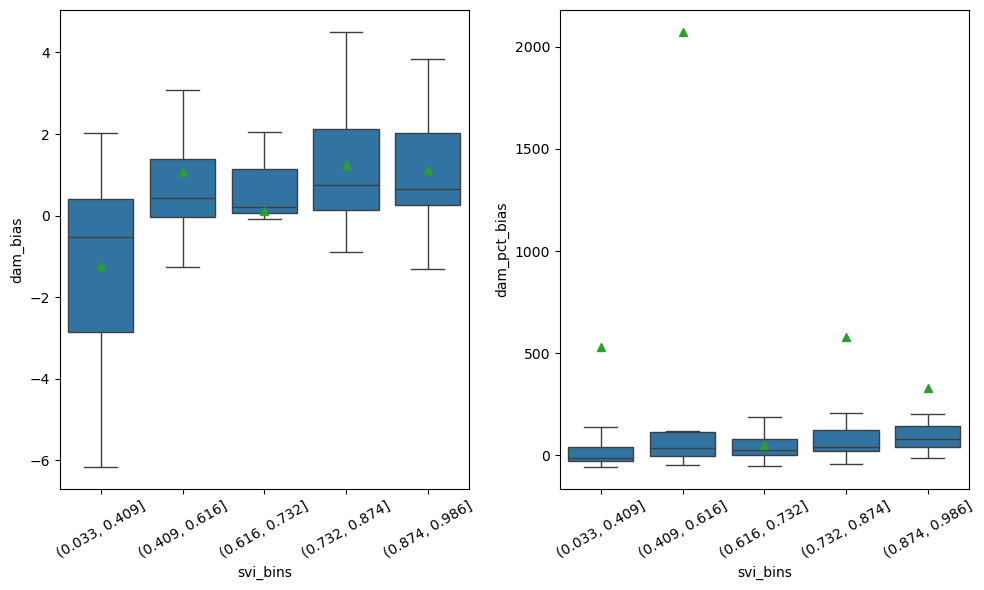

In [204]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 6))

sns.boxplot(data=temp,
            x='svi_bins',
            y='dam_bias',
            showmeans=True,
            showfliers=False,
            ax=ax[0])

sns.boxplot(data=temp,
            x='svi_bins',
            y='dam_pct_bias',
            showmeans=True,
            showfliers=False,
            ax=ax[1])

ax[0].tick_params('x', rotation=30)
ax[1].tick_params('x', rotation=30)

fig.tight_layout()